<a href="https://colab.research.google.com/github/JPAmewu/My_Capstone_1_Imperial/blob/main/Week_12_Capstone.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

# Week 12 Capstone — Bayesian Optimisation

This notebook appends the confirmed Week 11 observations to the Week 11 dataset, creating the Week 12 dataset before EDA and GP/UCB query selection.


For each function for Week_11, I will follow this sequence:
1. Create week_12_dataset
2. Extract function
3. Check shapes and missing values
4. Calculate summary statistics
5. Plot the output trend
6. Plot the best-so-far trend
7. Identify the best query point
8. Plot the correlation heatmap
9. Plot each input against the output
10. Fit a Gaussian Process surrogate
11. Apply UCB to generate the next query point

In [155]:
# Import libraries
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import os
import seaborn

In [156]:
# 1. Unzip the Week 11 dataset

import os
import shutil
import zipfile

import numpy as np

zip_path = "/content/week_11_dataset.zip"
extract_path = "/content/week_11_dataset"

# Remove an old extracted copy, if present.
if os.path.exists(extract_path):
    shutil.rmtree(extract_path)

os.makedirs(extract_path, exist_ok=True)

with zipfile.ZipFile(zip_path, "r") as zip_ref:
    zip_ref.extractall(extract_path)

print("Week 11 dataset extracted successfully.")


Week 11 dataset extracted successfully.


In [157]:
# 2. Check the extracted .npy files

for root, folders, files in os.walk(extract_path):
    for file in files:
        if file.endswith(".npy"):
            print(os.path.join(root, file))

/content/week_11_dataset/week_11_dataset/function_5_inputs.npy
/content/week_11_dataset/week_11_dataset/function_3_inputs.npy
/content/week_11_dataset/week_11_dataset/function_8_inputs.npy
/content/week_11_dataset/week_11_dataset/function_1_outputs.npy
/content/week_11_dataset/week_11_dataset/function_8_outputs.npy
/content/week_11_dataset/week_11_dataset/function_4_inputs.npy
/content/week_11_dataset/week_11_dataset/function_2_outputs.npy
/content/week_11_dataset/week_11_dataset/function_6_inputs.npy
/content/week_11_dataset/week_11_dataset/function_2_inputs.npy
/content/week_11_dataset/week_11_dataset/function_7_inputs.npy
/content/week_11_dataset/week_11_dataset/function_1_inputs.npy
/content/week_11_dataset/week_11_dataset/function_6_outputs.npy
/content/week_11_dataset/week_11_dataset/function_3_outputs.npy
/content/week_11_dataset/week_11_dataset/function_7_outputs.npy
/content/week_11_dataset/week_11_dataset/function_4_outputs.npy
/content/week_11_dataset/week_11_dataset/functio

In [158]:
import os

for root, dirs, files in os.walk("/content/week_11_dataset"):
    print("FOLDER:", root)
    for file in files:
        if file.endswith(".npy"):
            print("   ", file)

FOLDER: /content/week_11_dataset
FOLDER: /content/week_11_dataset/week_11_dataset
    function_5_inputs.npy
    function_3_inputs.npy
    function_8_inputs.npy
    function_1_outputs.npy
    function_8_outputs.npy
    function_4_inputs.npy
    function_2_outputs.npy
    function_6_inputs.npy
    function_2_inputs.npy
    function_7_inputs.npy
    function_1_inputs.npy
    function_6_outputs.npy
    function_3_outputs.npy
    function_7_outputs.npy
    function_4_outputs.npy
    function_5_outputs.npy


In [159]:
# 3. Load and validate the Week 11 dataset

EXPECTED_DIMENSIONS = {
    1: 2,
    2: 2,
    3: 3,
    4: 4,
    5: 4,
    6: 5,
    7: 6,
    8: 8,
}


def find_npy_file(folder, function_number, data_type):
    """Return the unique input or output array for a function."""
    if data_type not in {"input", "output"}:
        raise ValueError("data_type must be 'input' or 'output'.")

    expected_name = f"function_{function_number}_{data_type}s.npy"
    matching_files = sorted(
        os.path.join(root, filename)
        for root, _, files in os.walk(folder)
        for filename in files
        if filename.lower() == expected_name
    )

    if not matching_files:
        raise FileNotFoundError(
            f"No exact {data_type} file found for Function "
            f"{function_number}: {expected_name}"
        )

    if len(matching_files) > 1:
        raise RuntimeError(
            f"Multiple {data_type} files found for Function "
            f"{function_number}: {matching_files}"
        )

    return matching_files[0]


week_10_X = {}
week_10_y = {}

for function_number in range(1, 9):
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input",
    )
    output_file = find_npy_file(
        extract_path,
        function_number,
        "output",
    )

    expected_dimension = EXPECTED_DIMENSIONS[function_number]
    inputs = np.asarray(np.load(input_file), dtype=float)
    outputs = np.asarray(np.load(output_file), dtype=float).reshape(-1, 1)

    if inputs.ndim == 1:
        if inputs.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: {inputs.size} input values "
                f"cannot be reshaped to dimension {expected_dimension}."
            )
        inputs = inputs.reshape(-1, expected_dimension)

    if inputs.ndim != 2 or inputs.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected a two-dimensional input "
            f"array with {expected_dimension} columns, got {inputs.shape}."
        )

    if not np.isfinite(inputs).all() or not np.isfinite(outputs).all():
        raise ValueError(
            f"Function {function_number}: input or output contains "
            "non-finite values."
        )

    week_10_X[function_number] = inputs
    week_10_y[function_number] = outputs

    print(f"Function {function_number}")
    print("Input shape :", inputs.shape)
    print("Output shape:", outputs.shape)
    print("-" * 40)


Function 1
Input shape : (20, 2)
Output shape: (20, 1)
----------------------------------------
Function 2
Input shape : (20, 2)
Output shape: (20, 1)
----------------------------------------
Function 3
Input shape : (25, 3)
Output shape: (25, 1)
----------------------------------------
Function 4
Input shape : (40, 4)
Output shape: (40, 1)
----------------------------------------
Function 5
Input shape : (30, 4)
Output shape: (30, 1)
----------------------------------------
Function 6
Input shape : (30, 5)
Output shape: (30, 1)
----------------------------------------
Function 7
Input shape : (40, 6)
Output shape: (40, 1)
----------------------------------------
Function 8
Input shape : (49, 8)
Output shape: (49, 1)
----------------------------------------


In [160]:

# Validate Week 11 input-output alignment

for function_number in range(1, 9):

    input_file = find_npy_file(
        extract_path,
        function_number,
        "input"
    )

    output_file = find_npy_file(
        extract_path,
        function_number,
        "output"
    )

    inputs = np.load(input_file)
    outputs = np.load(output_file)

    print(
        f"Function {function_number}: "
        f"inputs {inputs.shape}, outputs {outputs.shape}"
    )

    if inputs.shape[0] != outputs.shape[0]:
        raise ValueError(
            f"Function {function_number}: "
            f"{inputs.shape[0]} inputs but {outputs.shape[0]} outputs"
        )

print("\nAll Week 11 input and output arrays are aligned.")


Function 1: inputs (20, 2), outputs (20, 1)
Function 2: inputs (20, 2), outputs (20, 1)
Function 3: inputs (25, 3), outputs (25, 1)
Function 4: inputs (40, 4), outputs (40, 1)
Function 5: inputs (30, 4), outputs (30, 1)
Function 6: inputs (30, 5), outputs (30, 1)
Function 7: inputs (40, 6), outputs (40, 1)
Function 8: inputs (49, 8), outputs (49, 1)

All Week 11 input and output arrays are aligned.


In [161]:
# Raw Week 11 files remain unchanged.

print("Validation complete; no source dataset files were overwritten.")

Validation complete; no source dataset files were overwritten.


In [162]:
# Confirmed Week 10 query points and returned outputs.
new_X = {key: np.array(value, dtype=float) for key, value in {1: [[0.379403, 0.071186]], 2: [[0.329121, 0.99795]], 3: [[0.447317, 0.65893, 0.324854]], 4: [[0.587928, 0.514452, 0.045793, 0.032616]], 5: [[0.005552, 0.918769, 0.692571, 0.988052]], 6: [[0.853051, 0.152023, 0.700695, 0.554516, 0.611033]], 7: [[0.107447, 0.625529, 0.309529, 0.130105, 0.44366, 0.667717]], 8: [[0.546897, 0.163123, 0.136484, 0.078398, 0.771803, 0.070794, 0.119397, 0.111488]]}.items()}
new_y = {key: np.array(value, dtype=float) for key, value in {1: [[-3.089423814911752e-96]], 2: [[0.049406406222616564]], 3: [[-0.08189344986506433]], 4: [[-23.42280313862202]], 5: [[430.8031249775375]], 6: [[-1.1717131510084098]], 7: [[1.009894033457839]], 8: [[9.6998918101966]]}.items()}

for function_number in range(1, 9):
    print(
        f"Function {function_number}: "
        f"input {new_X[function_number].shape}, "
        f"output {new_y[function_number].shape}"
    )


Function 1: input (1, 2), output (1, 1)
Function 2: input (1, 2), output (1, 1)
Function 3: input (1, 3), output (1, 1)
Function 4: input (1, 4), output (1, 1)
Function 5: input (1, 4), output (1, 1)
Function 6: input (1, 5), output (1, 1)
Function 7: input (1, 6), output (1, 1)
Function 8: input (1, 8), output (1, 1)


In [163]:
# Create Week 12 dataset by appending the new Week 11 query results
# to the complete Week 11 dataset

week_12_X = {}
week_12_y = {}

for function_number in range(1, 9):

    # Load the complete Week 11 dataset
    input_file = find_npy_file(
        extract_path,
        function_number,
        "input"
    )

    output_file = find_npy_file(
        extract_path,
        function_number,
        "output"
    )

    week_11_inputs = np.load(input_file)
    week_11_outputs = np.load(output_file)

    # Make sure output arrays are 1-dimensional
    week_11_outputs = np.asarray(week_11_outputs).reshape(-1)
    new_outputs = np.asarray(new_y[function_number]).reshape(-1)

    # Append Week 11's new query/result
    week_12_X[function_number] = np.vstack([
        week_11_inputs,
        new_X[function_number]
    ])

    week_12_y[function_number] = np.concatenate([
        week_11_outputs,
        new_outputs
    ])

    print(
        f"Function {function_number}: "
        f"Week 12 input {week_12_X[function_number].shape}, "
        f"output {week_12_y[function_number].shape}"
    )


Function 1: Week 12 input (21, 2), output (21,)
Function 2: Week 12 input (21, 2), output (21,)
Function 3: Week 12 input (26, 3), output (26,)
Function 4: Week 12 input (41, 4), output (41,)
Function 5: Week 12 input (31, 4), output (31,)
Function 6: Week 12 input (31, 5), output (31,)
Function 7: Week 12 input (41, 6), output (41,)
Function 8: Week 12 input (50, 8), output (50,)


In [164]:
from google.colab import drive

drive.mount("/content/drive")

week_12_folder = "/content/drive/MyDrive/week_12_dataset"
os.makedirs(week_12_folder, exist_ok=True)

for function_number in range(1, 9):
    input_file = os.path.join(
        week_12_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_file = os.path.join(
        week_12_folder,
        f"function_{function_number}_outputs.npy",
    )

    np.save(input_file, week_12_X[function_number])
    np.save(output_file, week_12_y[function_number])

print("Week 12 dataset saved successfully.")
print("Folder:", week_12_folder)


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
Week 12 dataset saved successfully.
Folder: /content/drive/MyDrive/week_12_dataset


In [165]:
for function_number in range(1, 9):

    saved_X = np.load(
        os.path.join(
            week_12_folder,
            f"function_{function_number}_inputs.npy"
        )
    )

    saved_y = np.load(
        os.path.join(
            week_12_folder,
            f"function_{function_number}_outputs.npy"
        )
    )

    status = (
        "MATCHED"
        if saved_X.shape[0] == saved_y.shape[0]
        else "NOT MATCHED"
    )

    print(
        f"Function {function_number}: "
        f"input {saved_X.shape}, "
        f"output {saved_y.shape} — {status}"
    )

Function 1: input (21, 2), output (21,) — MATCHED
Function 2: input (21, 2), output (21,) — MATCHED
Function 3: input (26, 3), output (26,) — MATCHED
Function 4: input (41, 4), output (41,) — MATCHED
Function 5: input (31, 4), output (31,) — MATCHED
Function 6: input (31, 5), output (31,) — MATCHED
Function 7: input (41, 6), output (41,) — MATCHED
Function 8: input (50, 8), output (50,) — MATCHED


In [166]:
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

sns.set_theme(style="whitegrid")




**Function**-by-function EDA function

1. Loading of inputs and outputs
2. Shape checks
3. Missing and infinite-value checks
4. Summary statistics
5. Output trend
6. Best-so-far trend
7. Best observed query point
8. Correlation heatmap
9. Input-output scatter plots
10. Top five observations

In [167]:
def conduct_function_eda(function_number, dataset_folder):
    """
    Conduct exploratory data analysis for one black-box function.

    Parameters
    ----------
    function_number : int
        Function number from 1 to 8.

    dataset_folder : str
        Folder containing the .npy files.
    """

    # ---------------------------------------------------------
    # 1. Build the file paths
    # ---------------------------------------------------------
    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy"
    )

    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy"
    )

    # ---------------------------------------------------------
    # 2. Check that the files exist
    # ---------------------------------------------------------
    if not os.path.exists(input_path):
        raise FileNotFoundError(
            f"Input file not found: {input_path}"
        )

    if not os.path.exists(output_path):
        raise FileNotFoundError(
            f"Output file not found: {output_path}"
        )

    # ---------------------------------------------------------
    # 3. Load the arrays
    # ---------------------------------------------------------
    X = np.load(input_path)
    y = np.load(output_path)

    # Make sure X is two-dimensional
    if X.ndim == 1:
        X = X.reshape(-1, 1)

    # Convert output from shape (n, 1) into shape (n,)
    y = y.reshape(-1)

    # ---------------------------------------------------------
    # 4. Check input-output matching
    # ---------------------------------------------------------
    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number} is not matched: "
            f"{X.shape[0]} input rows and {y.shape[0]} outputs."
        )

    # ---------------------------------------------------------
    # 5. Create a DataFrame
    # ---------------------------------------------------------
    input_columns = [
        f"x{i + 1}" for i in range(X.shape[1])
    ]

    df = pd.DataFrame(
        X,
        columns=input_columns
    )

    df["output"] = y

    # ---------------------------------------------------------
    # 6. Basic information
    # ---------------------------------------------------------
    print("\n")
    print("=" * 70)
    print(f"FUNCTION {function_number} EDA")
    print("=" * 70)

    print("\nDataset structure")
    print("-" * 40)
    print("Input shape :", X.shape)
    print("Output shape:", y.shape)
    print("Observations:", X.shape[0])
    print("Dimensions  :", X.shape[1])

    print("\nFirst five observations")
    print("-" * 40)
    display(df.head())

    # ---------------------------------------------------------
    # 7. Data-quality checks
    # ---------------------------------------------------------
    missing_values = df.isnull().sum()
    infinite_values = pd.Series(
        np.isinf(df.to_numpy()).sum(axis=0),
        index=df.columns
    )

    duplicate_rows = df.duplicated().sum()

    print("\nMissing values")
    print("-" * 40)
    print(missing_values)

    print("\nInfinite values")
    print("-" * 40)
    print(infinite_values)

    print("\nDuplicate rows")
    print("-" * 40)
    print(duplicate_rows)

    # ---------------------------------------------------------
    # 8. Summary statistics
    # ---------------------------------------------------------
    summary = df.describe().T

    summary["median"] = df.median()
    summary["variance"] = df.var()
    summary["skewness"] = df.skew()

    print("\nSummary statistics")
    print("-" * 40)
    display(summary)

    # ---------------------------------------------------------
    # 9. Find the best observed result
    # Maximisation objective
    # ---------------------------------------------------------
    best_index = int(np.argmax(y))
    best_output = float(y[best_index])
    best_input = X[best_index]

    print("\nBest observed result")
    print("-" * 40)
    print("Best array index       :", best_index)
    print("Best observation number:", best_index + 1)
    print("Best query point       :", best_input)
    print("Best output value      :", best_output)

    # ---------------------------------------------------------
    # 10. Top five observations
    # ---------------------------------------------------------
    top_five = (
        df.sort_values(
            by="output",
            ascending=False
        )
        .head(5)
    )

    print("\nTop five observations")
    print("-" * 40)
    display(top_five)

    # ---------------------------------------------------------
    # 11. Output trend
    # ---------------------------------------------------------
    observation_numbers = np.arange(1, len(y) + 1)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        y,
        marker="o"
    )

    plt.scatter(
        best_index + 1,
        best_output,
        marker="*",
        s=250,
        label="Best observed output"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Output")
    plt.title(
        f"Function {function_number}: Output Trend"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 12. Best-so-far trend
    # ---------------------------------------------------------
    best_so_far = np.maximum.accumulate(y)

    plt.figure(figsize=(11, 5))

    plt.plot(
        observation_numbers,
        best_so_far,
        marker="o"
    )

    plt.xlabel("Observation number")
    plt.ylabel("Best output found so far")
    plt.title(
        f"Function {function_number}: Best-So-Far Trend"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 13. Output distribution
    # ---------------------------------------------------------
    plt.figure(figsize=(9, 5))

    plt.hist(
        y,
        bins= 8,
        edgecolor="black"
    )

    plt.axvline(
        np.mean(y),
        linestyle="--",
        label=f"Mean = {np.mean(y):.5g}"
    )

    plt.axvline(
        np.median(y),
        linestyle=":",
        label=f"Median = {np.median(y):.5g}"
    )

    plt.xlabel("Output")
    plt.ylabel("Frequency")
    plt.title(
        f"Function {function_number}: Output Distribution"
    )

    plt.legend()
    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 14. Correlation heatmap
    # ---------------------------------------------------------
    correlation = df.corr(numeric_only=True)

    plt.figure(
        figsize=(
            max(7, X.shape[1] + 3),
            max(5, X.shape[1] + 2)
        )
    )

    sns.heatmap(
        correlation,
        annot=True,
        fmt=".2f",
        cmap="coolwarm",
        center=0
    )

    plt.title(
        f"Function {function_number}: Correlation Heatmap"
    )

    plt.tight_layout()
    plt.show()

    # ---------------------------------------------------------
    # 15. Each input against the output
    # ---------------------------------------------------------
    for column in input_columns:

        plt.figure(figsize=(8, 5))

        plt.scatter(
            df[column],
            df["output"],
            alpha=0.75
        )

        plt.scatter(
            df.loc[best_index, column],
            df.loc[best_index, "output"],
            marker="*",
            s=250,
            label="Best observed point"
        )

        plt.xlabel(column)
        plt.ylabel("Output")

        plt.title(
            f"Function {function_number}: "
            f"{column} Against Output"
        )

        plt.legend()
        plt.tight_layout()
        plt.show()

    # ---------------------------------------------------------
    # 16. Input-output correlations
    # ---------------------------------------------------------
    output_correlations = (
        correlation["output"]
        .drop("output")
        .sort_values(
            key=lambda values: values.abs(),
            ascending=False
        )
    )

    print("\nInput-output correlations")
    print("-" * 40)
    print(output_correlations)

    # ---------------------------------------------------------
    # 17. Concise report
    # ---------------------------------------------------------
    print("\nConcise EDA report")
    print("-" * 40)

    print(f"Observations       : {X.shape[0]}")
    print(f"Input dimensions   : {X.shape[1]}")
    print(f"Missing values     : {df.isnull().sum().sum()}")
    print(f"Infinite values    : {np.isinf(df.to_numpy()).sum()}")
    print(f"Duplicate rows     : {duplicate_rows}")
    print(f"Minimum output     : {np.min(y):.10g}")
    print(f"Mean output        : {np.mean(y):.10g}")
    print(f"Median output      : {np.median(y):.10g}")
    print(f"Maximum output     : {np.max(y):.10g}")
    print(f"Best observation   : {best_index + 1}")
    print(f"Best query point   : {best_input}")
    print(f"Best output        : {best_output:.10g}")

    # Return the important objects
    return {
        "function": function_number,
        "X": X,
        "y": y,
        "dataframe": df,
        "summary": summary,
        "correlation": correlation,
        "best_index": best_index,
        "best_input": best_input,
        "best_output": best_output,
        "best_so_far": best_so_far,
        "top_five": top_five
    }



FUNCTION 1 EDA

Dataset structure
----------------------------------------
Input shape : (21, 2)
Output shape: (21,)
Observations: 21
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.319404,0.762959,1.322677e-79
1,0.574329,0.879898,1.033078e-46
2,0.731024,0.733000,7.710875e-16
3,0.840353,0.264732,3.341771e-124
4,0.650114,0.681526,-3.606063e-03



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,21.0,0.508902,0.232307,0.082507,3.745400e-01,3.794030e-01,6.834182e-01,0.897714,3.794030e-01,0.053967,0.494196
x2,21.0,0.589994,0.374634,0.071186,1.475543e-01,7.329999e-01,9.507140e-01,0.999543,7.329999e-01,0.140351,-0.425891
output,21.0,12.190304,25.752015,-0.003606,-3.089424e-96,3.341771e-124,2.535001e-40,64.000000,3.341771e-124,663.166301,1.700435



Best observed result
----------------------------------------
Best array index       : 10
Best observation number: 11
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
11,0.374540,0.950714,6.400000e+01
13,0.374540,0.950714,6.400000e+01
10,0.374540,0.950714,6.400000e+01
12,0.374540,0.950714,6.400000e+01
2,0.731024,0.733000,7.710875e-16


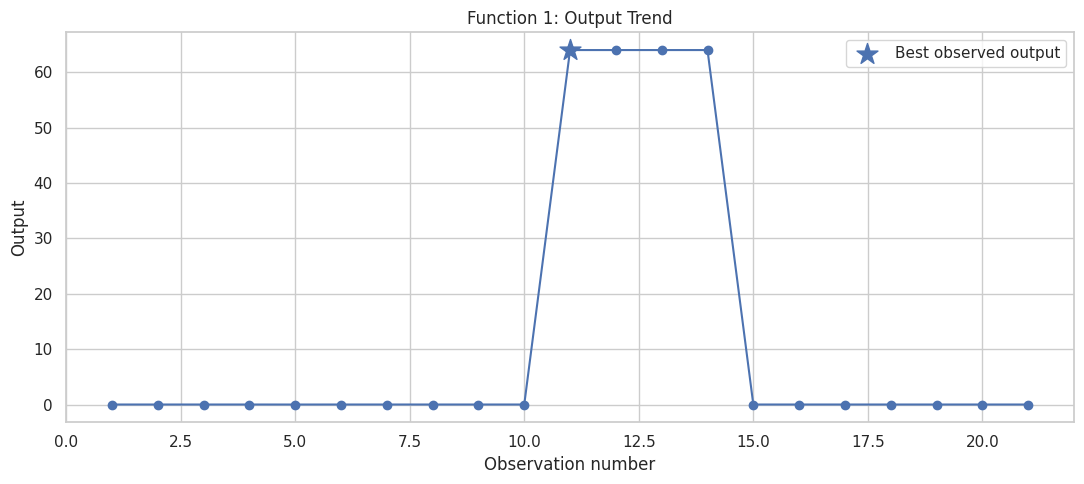

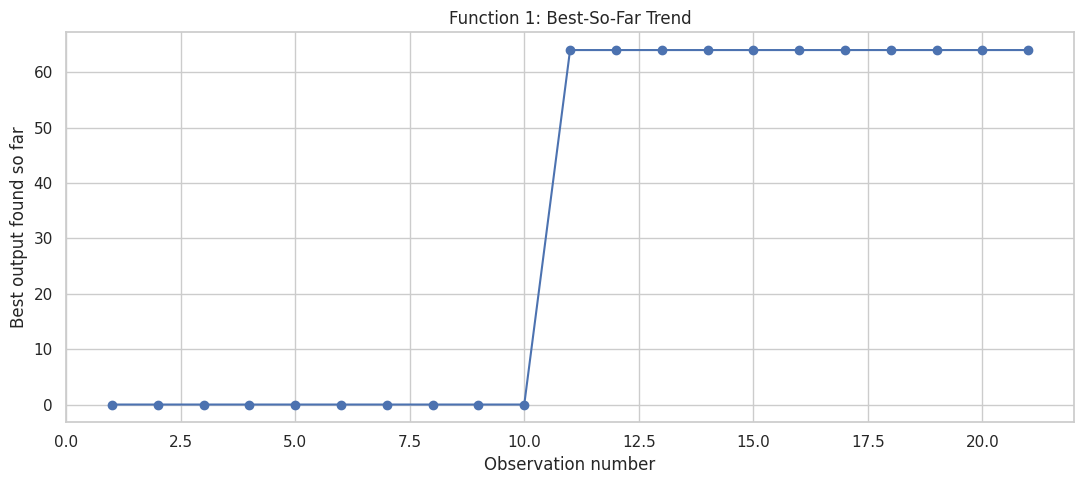

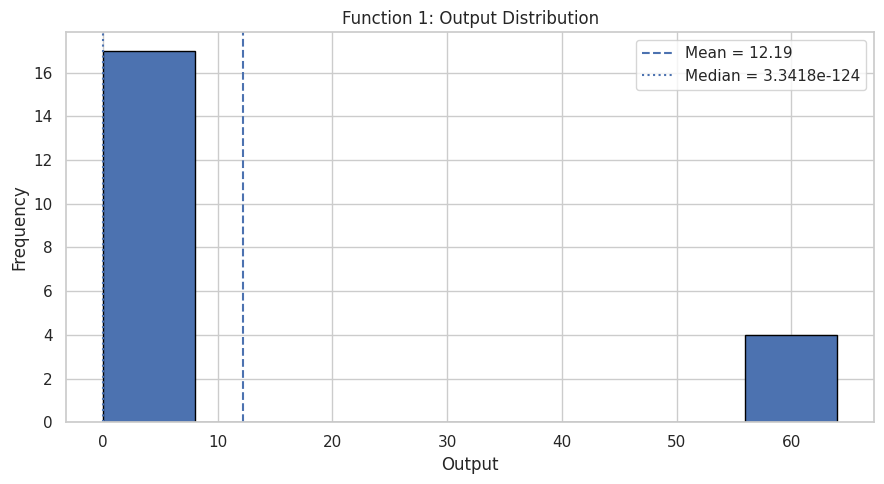

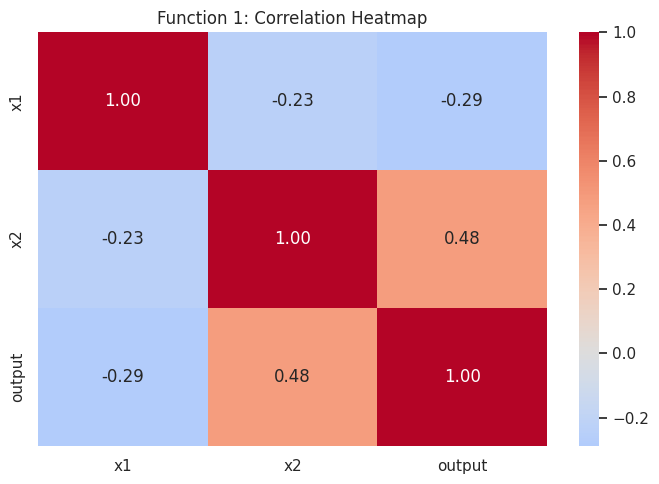

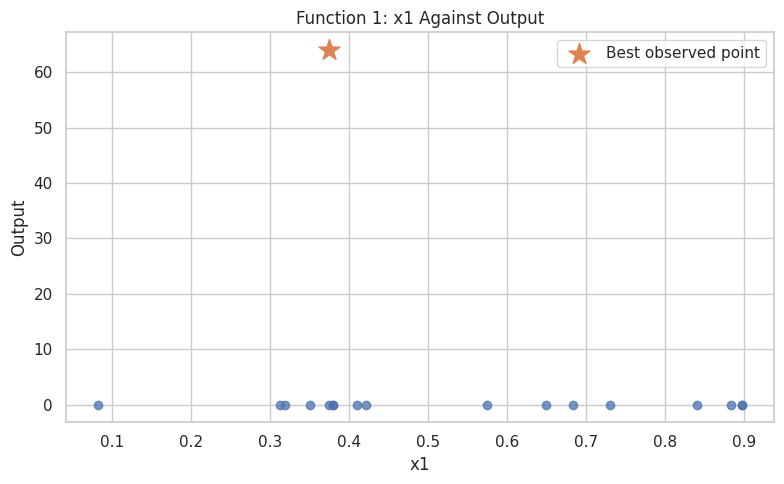

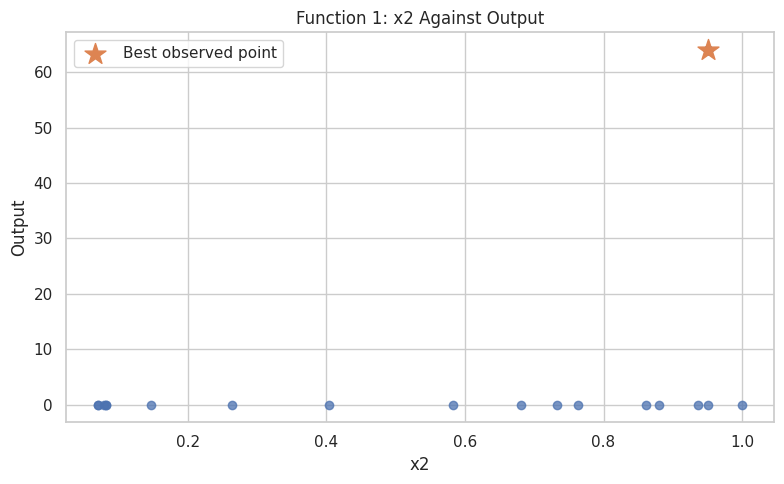


Input-output correlations
----------------------------------------
x2    0.478586
x1   -0.287486
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 21
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.003606062644
Mean output        : 12.19030447
Median output      : 3.341771008e-124
Maximum output     : 64
Best observation   : 11
Best query point   : [0.37454  0.950714]
Best output        : 64


In [168]:
# Conduct Function 1 EDA


eda_1 = conduct_function_eda(
    function_number=1,
    dataset_folder=week_12_folder
)



FUNCTION 2 EDA

Dataset structure
----------------------------------------
Input shape : (21, 2)
Output shape: (21,)
Observations: 21
Dimensions  : 2

First five observations
----------------------------------------


,x1,x2,output
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
2,0.142699,0.349005,-0.065624
3,0.845275,0.711120,0.293993
4,0.454647,0.290455,0.214965



Missing values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,21.0,0.477703,0.238720,0.009675,3.417496e-01,0.374540,0.577713,0.995366,0.374540,0.056987,0.466965
x2,21.0,0.640631,0.351224,0.028698,3.490051e-01,0.771973,0.950714,0.999881,0.771973,0.123358,-0.505782
output,21.0,3.186353,13.935456,-0.065624,-1.560647e-117,0.049406,0.244619,64.000000,0.049406,194.196925,4.581163



Best observed result
----------------------------------------
Best array index       : 13
Best observation number: 14
Best query point       : [0.37454  0.950714]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,output
13,0.374540,0.950714,64.000000
9,0.702637,0.926564,0.611205
0,0.665800,0.123969,0.538996
1,0.877791,0.778628,0.420586
3,0.845275,0.711120,0.293993


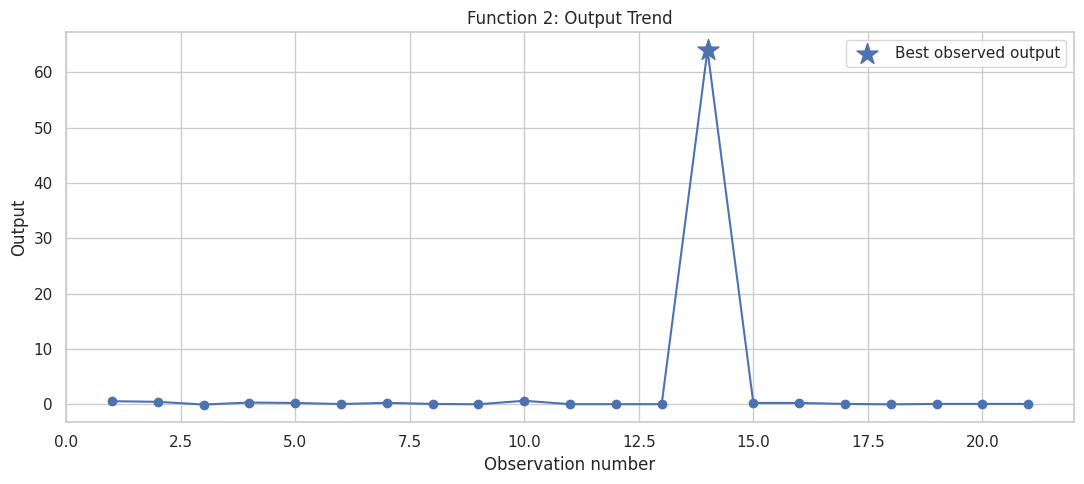

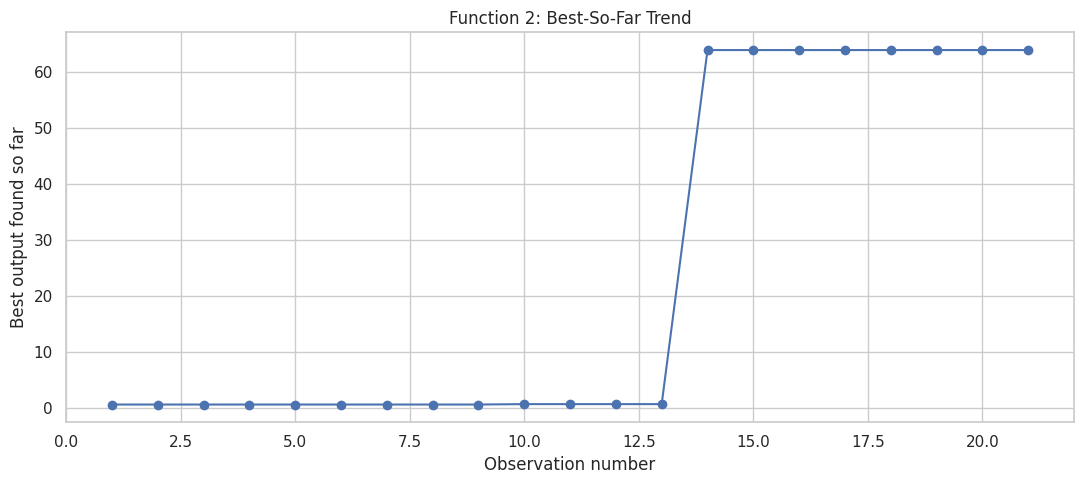

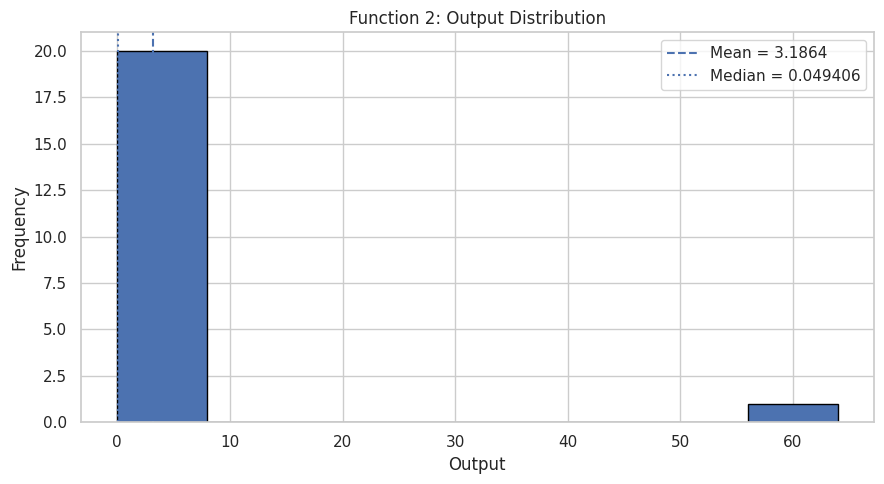

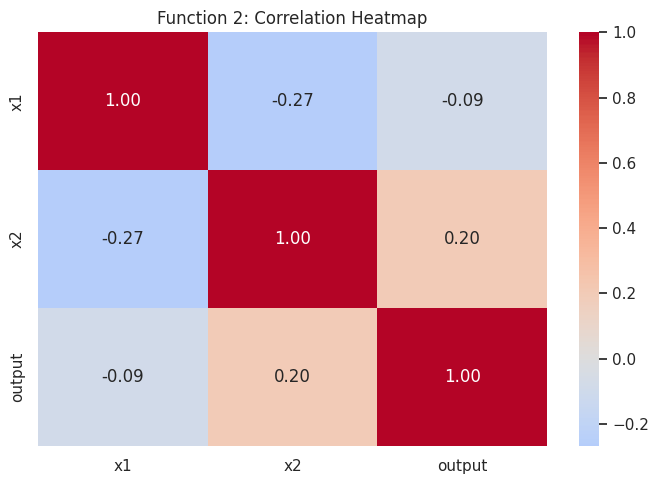

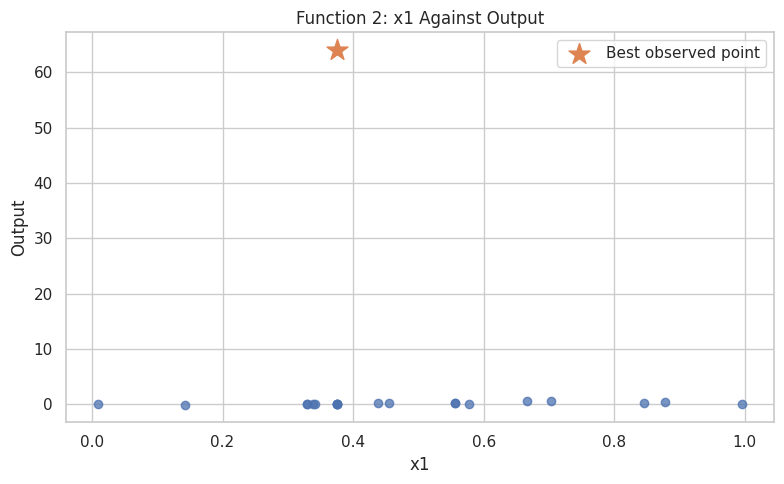

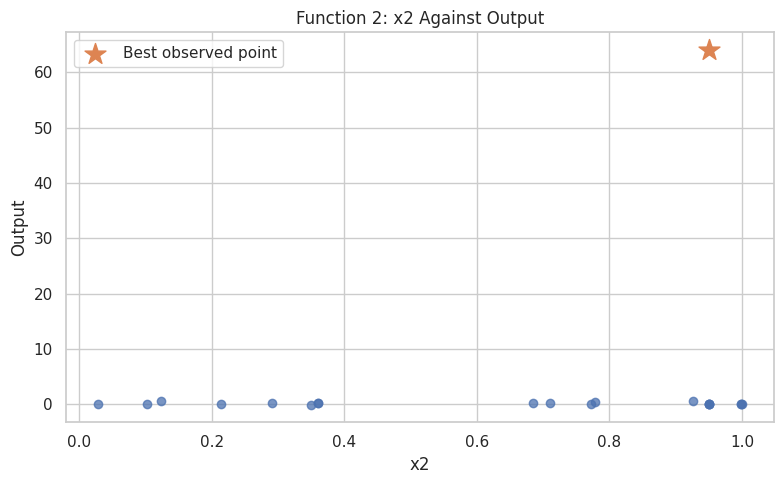


Input-output correlations
----------------------------------------
x2    0.200770
x1   -0.091011
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 21
Input dimensions   : 2
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.06562362444
Mean output        : 3.186352534
Median output      : 0.04940640622
Maximum output     : 64
Best observation   : 14
Best query point   : [0.37454  0.950714]
Best output        : 64


In [169]:
# Conduct Function 2 EDA
eda_2 = conduct_function_eda(
    function_number=2,
    dataset_folder=week_12_folder
)



FUNCTION 3 EDA

Dataset structure
----------------------------------------
Input shape : (26, 3)
Output shape: (26,)
Observations: 26
Dimensions  : 3

First five observations
----------------------------------------


,x1,x2,x3,output
0,0.171525,0.343917,0.248737,-0.112122
1,0.242114,0.644074,0.272433,-0.087963
2,0.534906,0.398501,0.173389,-0.111415
3,0.492581,0.611593,0.340176,-0.034835
4,0.134622,0.219917,0.458206,-0.048008



Missing values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,26.0,0.429770,0.208304,0.046809,0.267967,0.444444,0.522591,0.965995,0.444444,0.043390,0.301662
x2,26.0,0.535842,0.229017,0.090709,0.357223,0.658930,0.666666,0.941360,0.658930,0.052449,-0.515917
x3,26.0,0.380586,0.216761,0.066089,0.270131,0.333333,0.424351,0.990882,0.333333,0.046985,1.641672
output,26.0,9.767074,23.583062,-0.398926,-0.109457,-0.069645,-0.042418,64.000000,-0.069645,556.160802,2.038303



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.444444 0.666666 0.333333]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,output
17,0.444444,0.666666,0.333333,64.000000
16,0.444444,0.666666,0.333333,64.000000
18,0.444444,0.666666,0.333333,64.000000
15,0.444444,0.666666,0.333333,64.000000
3,0.492581,0.611593,0.340176,-0.034835


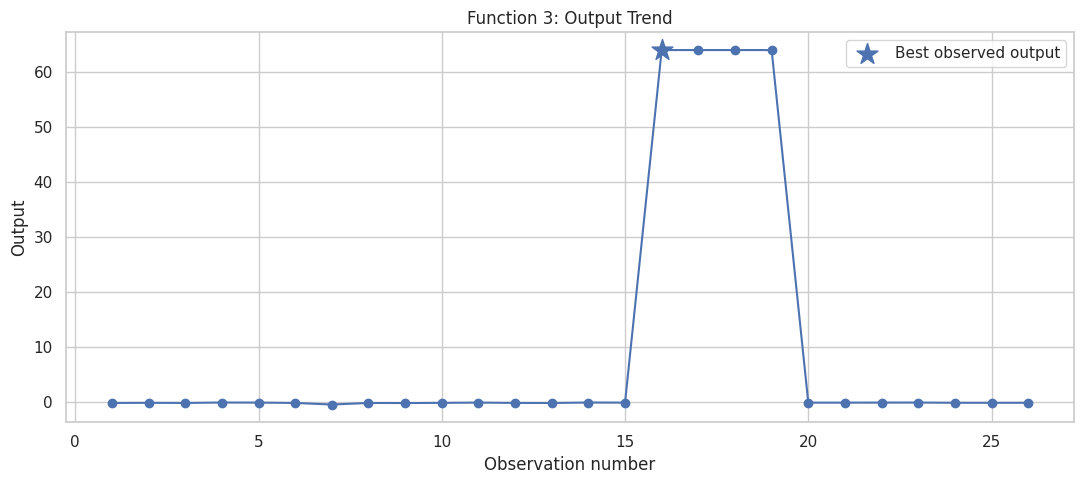

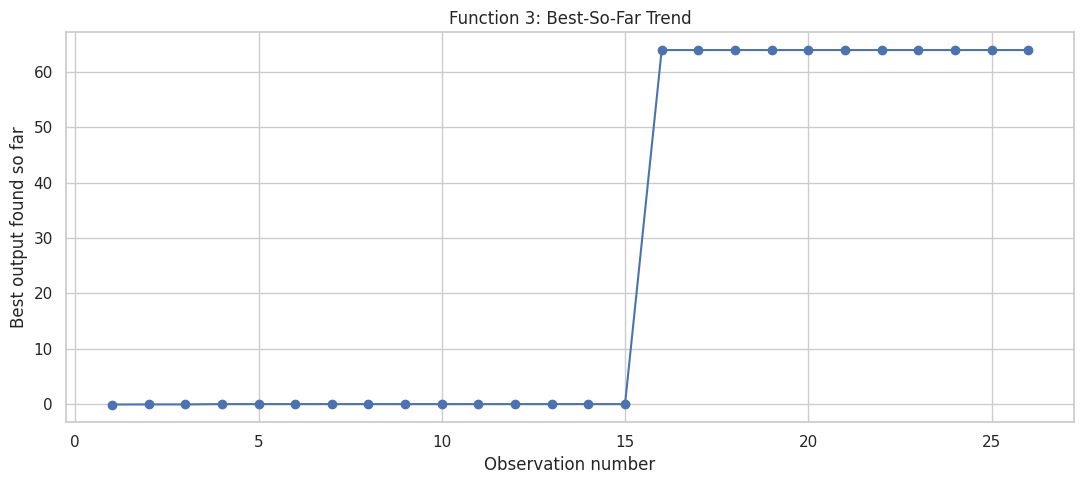

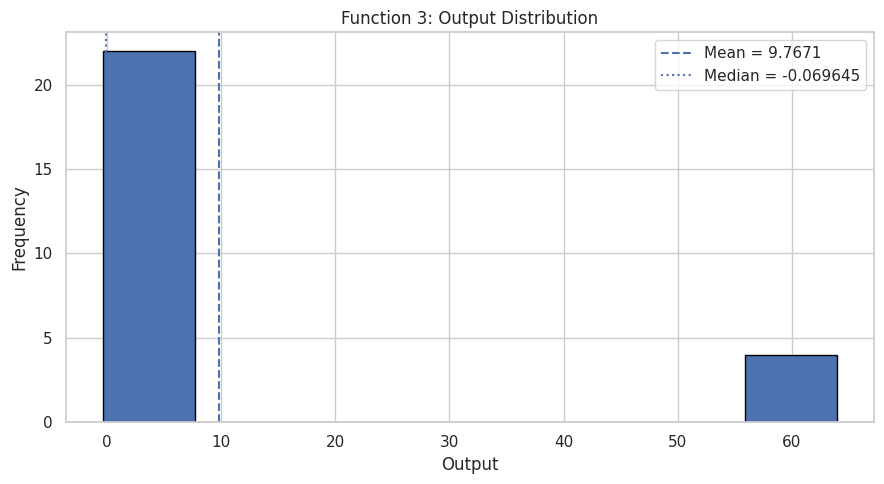

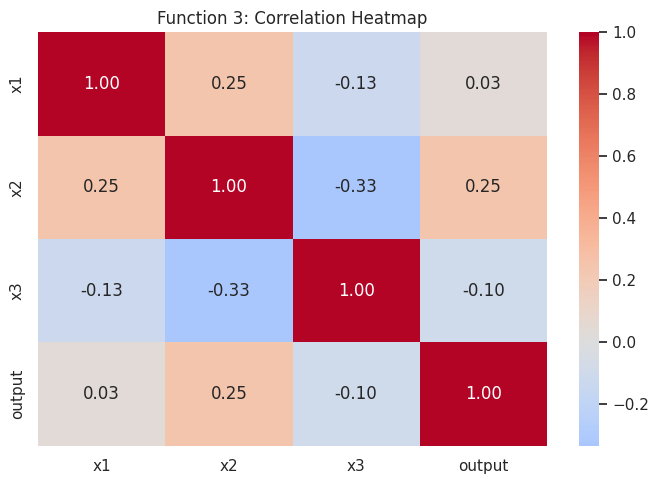

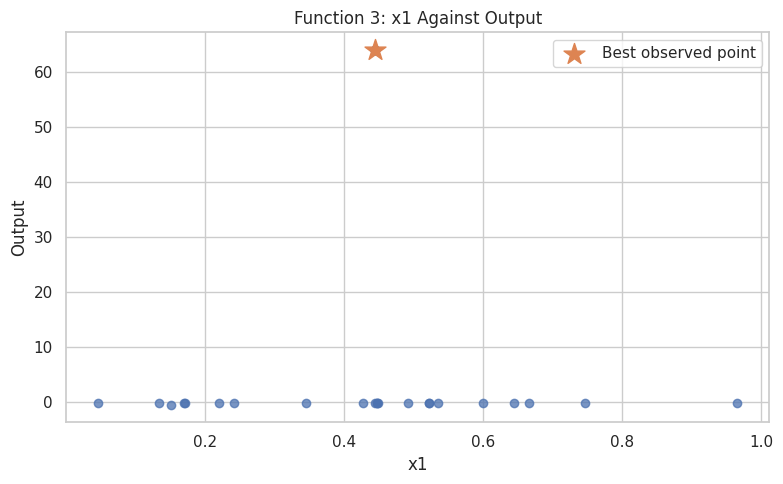

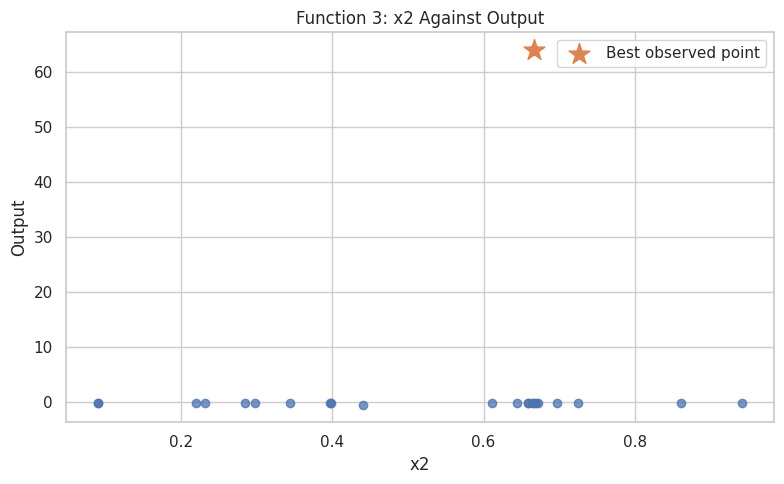

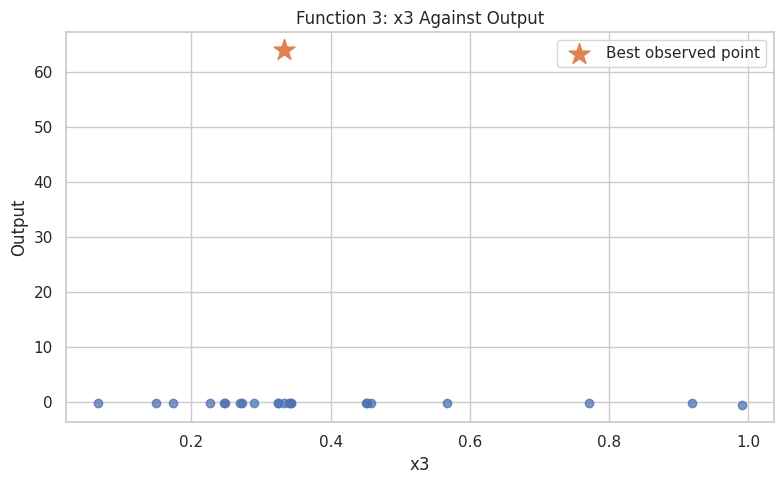


Input-output correlations
----------------------------------------
x2    0.248654
x3   -0.096397
x1    0.031417
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 26
Input dimensions   : 3
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -0.3989255131
Mean output        : 9.767074234
Median output      : -0.06964527577
Maximum output     : 64
Best observation   : 16
Best query point   : [0.444444 0.666666 0.333333]
Best output        : 64


In [170]:
# Conduct Function 3 EDA
eda_3 = conduct_function_eda(
    function_number=3,
    dataset_folder=week_12_folder
)



FUNCTION 4 EDA

Dataset structure
----------------------------------------
Input shape : (41, 4)
Output shape: (41,)
Observations: 41
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.896981,0.725628,0.175404,0.701694,-22.108288
1,0.889356,0.499588,0.539269,0.508783,-14.601397
2,0.250946,0.033693,0.145380,0.494932,-11.699932
3,0.346962,0.006250,0.760564,0.613024,-16.053765
4,0.124871,0.129770,0.384400,0.287076,-10.069633



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,41.0,0.552508,0.268611,0.037825,0.326076,0.577766,0.738613,0.985622,0.577766,0.072152,-0.229520
x2,41.0,0.438864,0.287092,0.002958,0.166086,0.472367,0.664853,0.919592,0.472367,0.082422,-0.008228
x3,41.0,0.382463,0.271344,0.014095,0.175404,0.335420,0.539269,0.939178,0.335420,0.073627,0.473504
x4,41.0,0.386152,0.307738,0.032616,0.111111,0.253924,0.701694,0.999483,0.253924,0.094703,0.491774
output,41.0,-14.348720,14.849198,-32.625660,-22.108288,-16.053765,-11.699932,64.000000,-16.053765,220.498689,3.766282



Best observed result
----------------------------------------
Best array index       : 33
Best observation number: 34
Best query point       : [0.555555 0.444444 0.222222 0.111111]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
33,0.555555,0.444444,0.222222,0.111111,64.000000
30,0.555555,0.444444,0.222222,0.111111,-0.031830
31,0.555555,0.444444,0.222222,0.111111,-0.031830
32,0.555555,0.444444,0.222222,0.111111,-0.031830
27,0.577766,0.428772,0.425826,0.249007,-4.025542


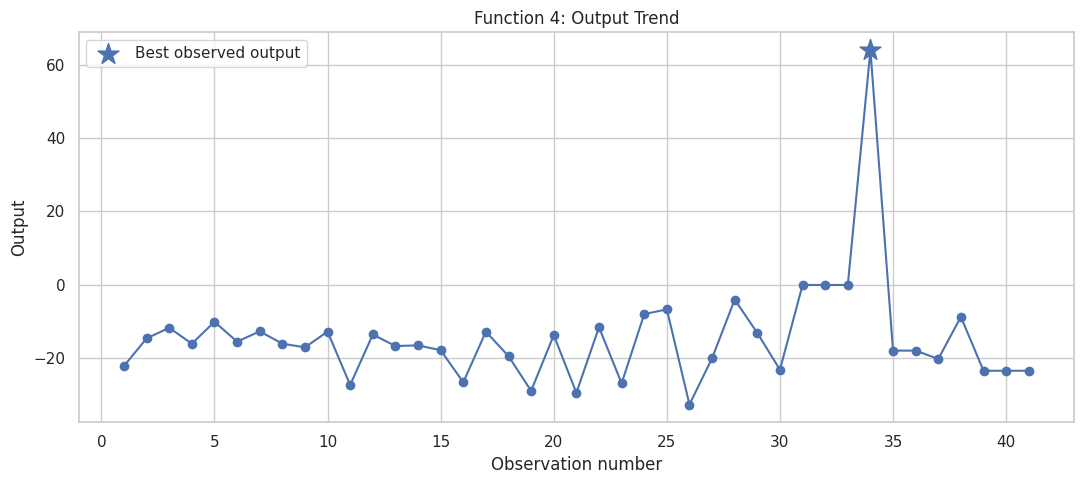

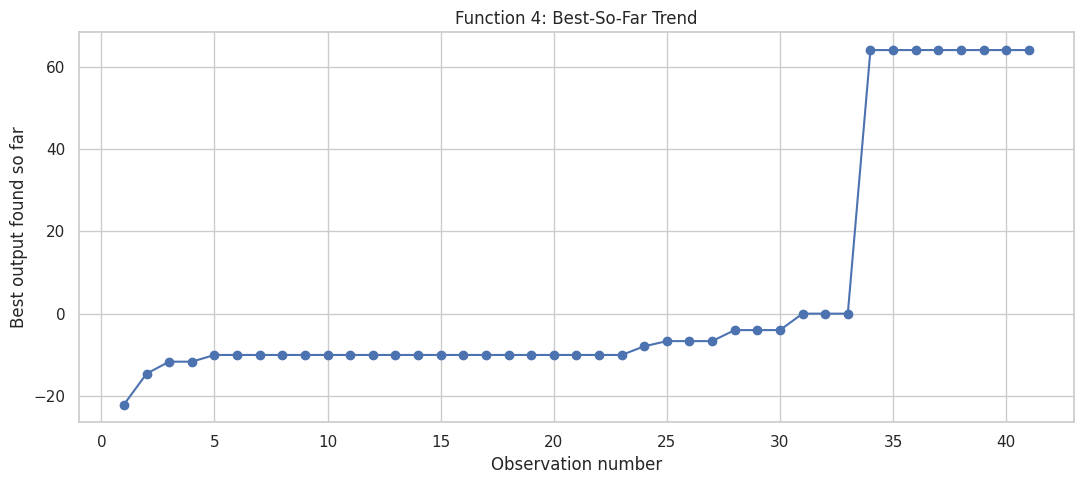

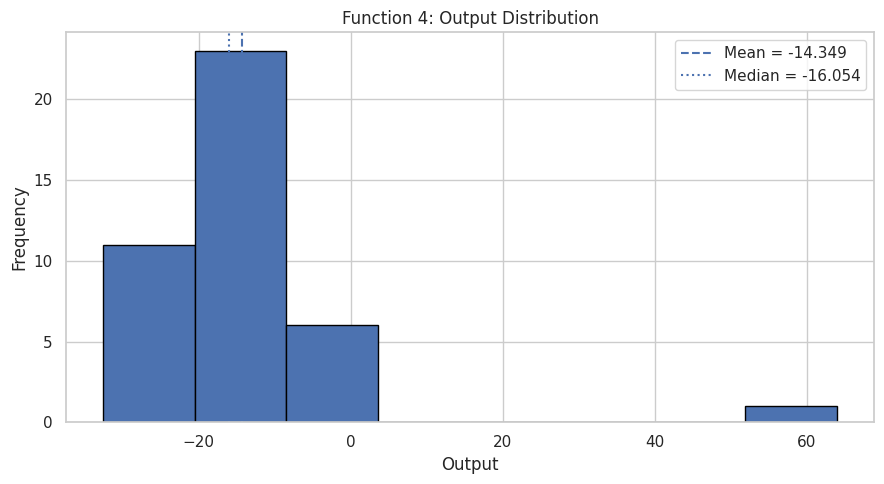

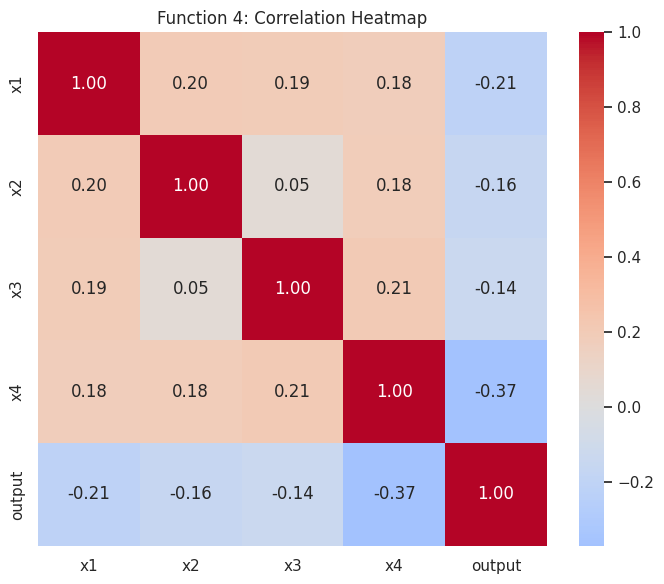

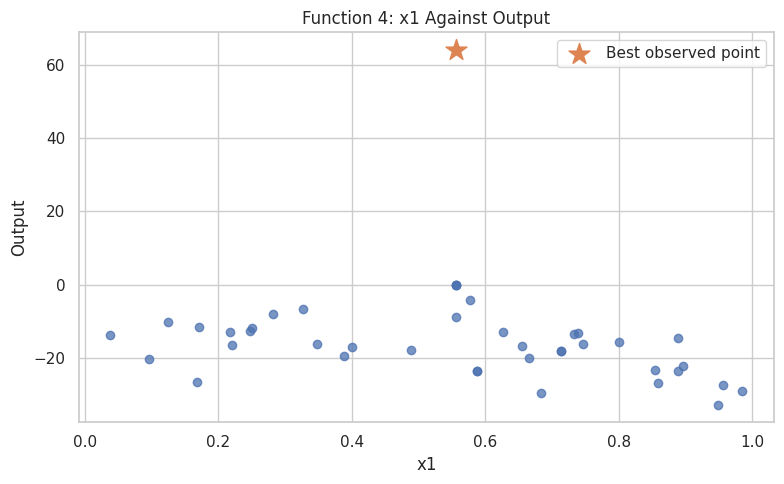

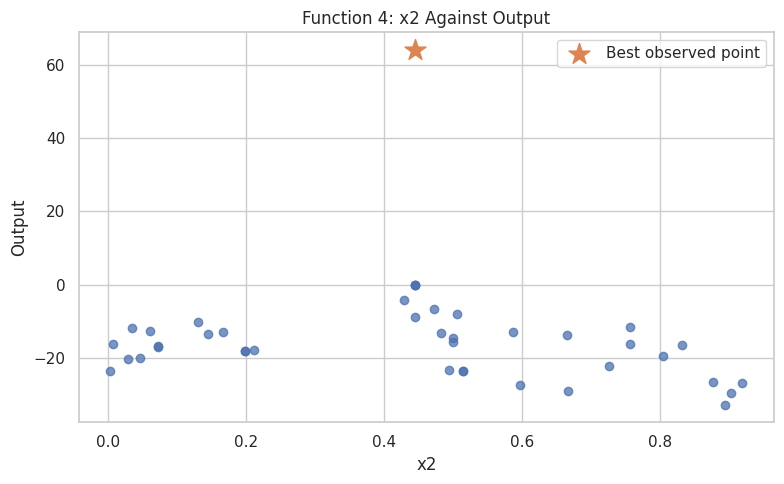

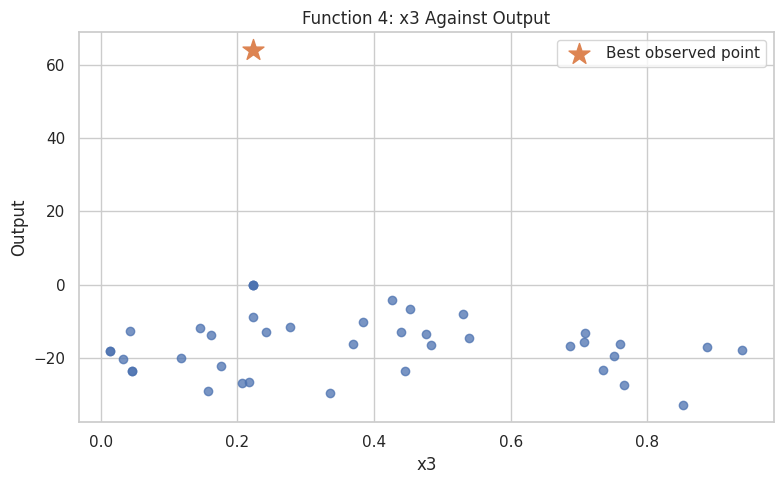

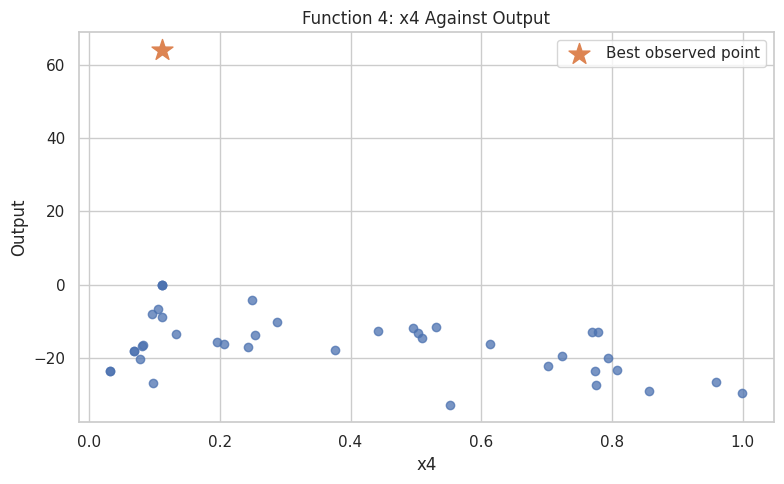


Input-output correlations
----------------------------------------
x4   -0.370761
x1   -0.211980
x2   -0.157789
x3   -0.136098
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 41
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -32.62566022
Mean output        : -14.34871956
Median output      : -16.05376511
Maximum output     : 64
Best observation   : 34
Best query point   : [0.555555 0.444444 0.222222 0.111111]
Best output        : 64


In [171]:
# Conduct Function 4 EDA
eda_4 = conduct_function_eda(
    function_number=4,
    dataset_folder=week_12_folder
)



FUNCTION 5 EDA

Dataset structure
----------------------------------------
Input shape : (31, 4)
Output shape: (31,)
Observations: 31
Dimensions  : 4

First five observations
----------------------------------------


,x1,x2,x3,x4,output
0,0.191447,0.038193,0.607418,0.414584,64.443440
1,0.758653,0.536518,0.656000,0.360342,18.301380
2,0.438350,0.804340,0.210245,0.151295,0.112940
3,0.706051,0.534192,0.264243,0.482088,4.210898
4,0.836478,0.193610,0.663893,0.785649,258.370525



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
5

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,31.0,0.392547,0.254013,0.00000,0.224189,0.352356,0.630732,0.836478,0.352356,0.064523,0.202983
x2,31.0,0.571794,0.288359,0.00000,0.340376,0.639619,0.846480,0.918769,0.639619,0.083151,-0.600957
x3,31.0,0.536743,0.269753,0.00000,0.363132,0.607418,0.749436,0.879484,0.607418,0.072767,-0.325933
x4,31.0,0.576682,0.336317,0.00000,0.307039,0.567577,0.878515,1.000000,0.567577,0.113109,-0.272200
output,31.0,187.990424,280.097195,0.11294,26.644920,64.000000,245.797068,1088.859618,64.000000,78454.438583,2.355448



Best observed result
----------------------------------------
Best array index       : 15
Best observation number: 16
Best query point       : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output value      : 1088.8596181962705

Top five observations
----------------------------------------


,x1,x2,x3,x4,output
15,0.224189,0.846480,0.879484,0.878516,1088.859618
27,0.224189,0.846480,0.879484,0.878515,1088.853511
18,0.119879,0.862540,0.643331,0.849804,431.612757
30,0.005552,0.918769,0.692571,0.988052,430.803125
29,0.005552,0.918769,0.692571,0.988052,430.803125


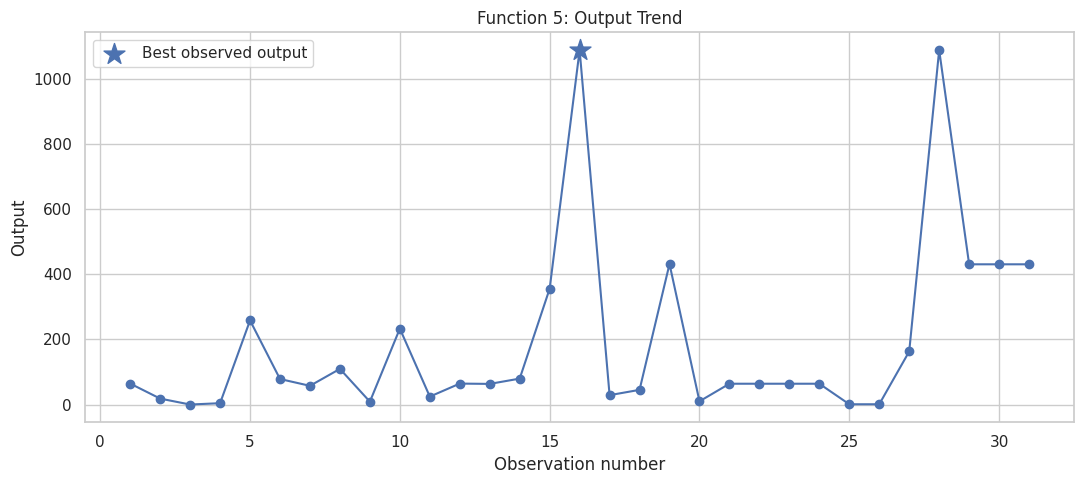

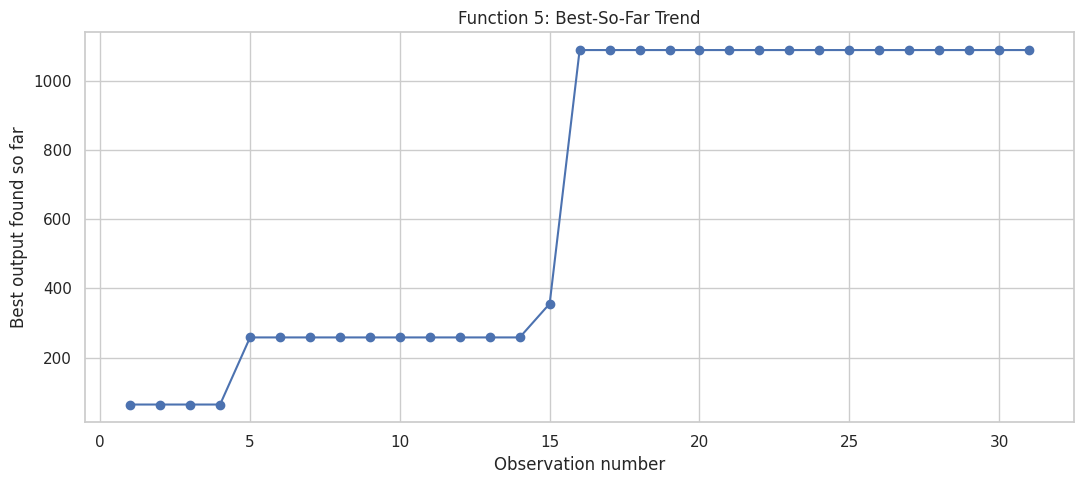

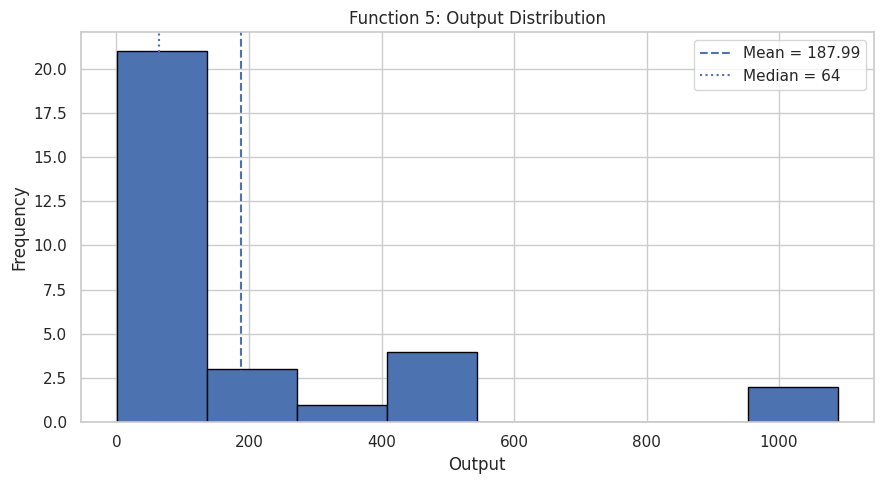

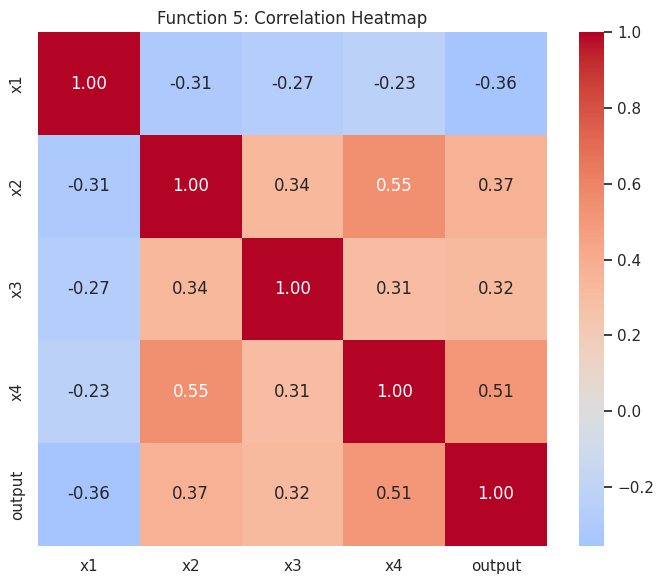

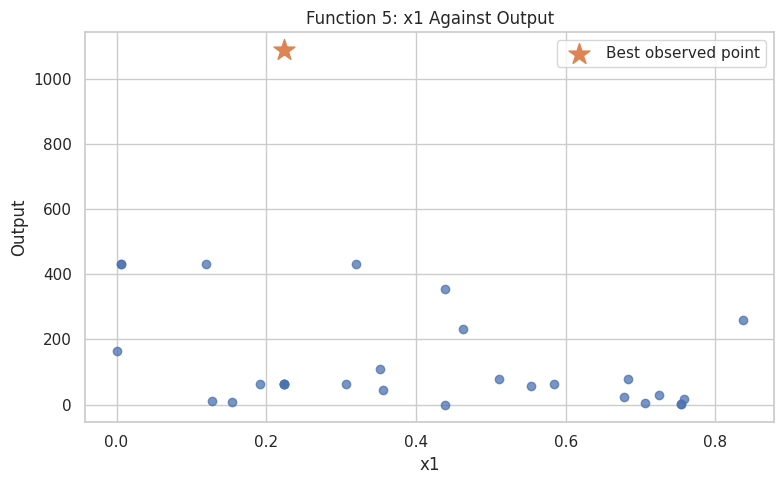

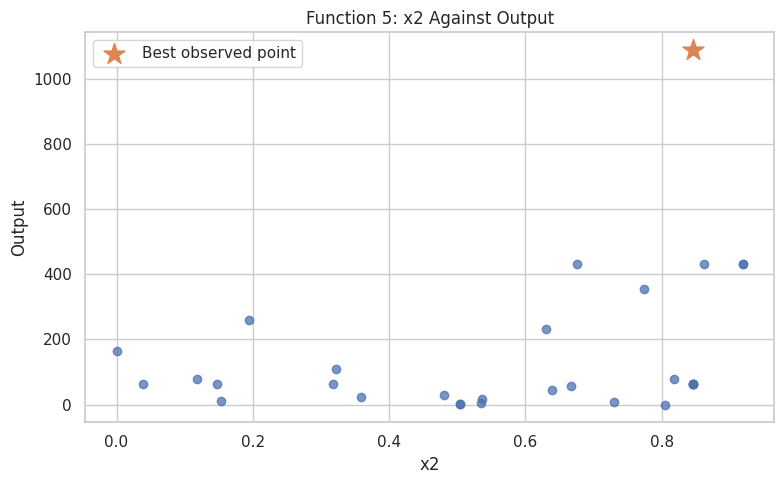

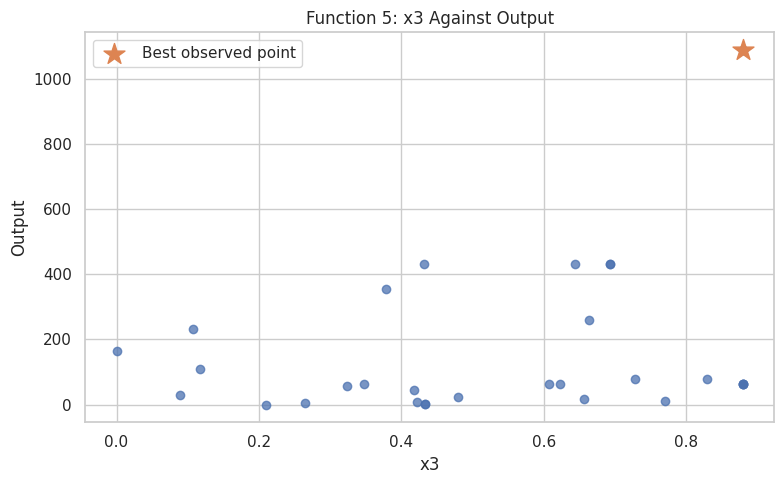

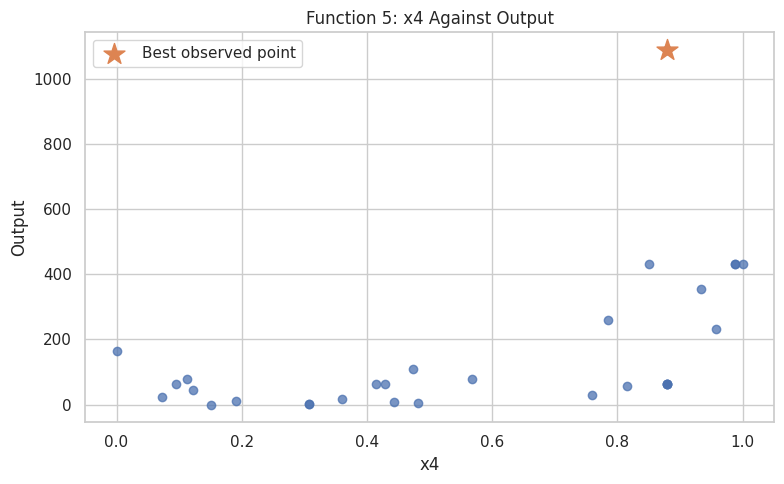


Input-output correlations
----------------------------------------
x4    0.510140
x2    0.374738
x1   -0.355375
x3    0.316857
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 31
Input dimensions   : 4
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 5
Minimum output     : 0.1129397954
Mean output        : 187.9904236
Median output      : 64
Maximum output     : 1088.859618
Best observation   : 16
Best query point   : [0.22418902 0.84648049 0.87948418 0.87851568]
Best output        : 1088.859618


In [172]:
# Conduct Function 5 EDA
eda_5 = conduct_function_eda(
    function_number=5,
    dataset_folder=week_12_folder
)



FUNCTION 6 EDA

Dataset structure
----------------------------------------
Input shape : (31, 5)
Output shape: (31,)
Observations: 31
Dimensions  : 5

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265
1,0.242384,0.844100,0.577809,0.679021,0.501953,-1.209955
2,0.729523,0.748106,0.679775,0.356552,0.671054,-1.672200
3,0.770620,0.114404,0.046780,0.648324,0.273549,-1.536058
4,0.618812,0.331802,0.187288,0.756238,0.328835,-0.829237



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,31.0,0.624078,0.265296,0.021735,0.488071,0.728186,0.783919,0.957740,0.728186,0.070382,-1.019838
x2,31.0,0.405977,0.313459,0.022732,0.154693,0.291470,0.731862,0.931871,0.291470,0.098257,0.522605
x3,31.0,0.575696,0.296789,0.016523,0.413378,0.700695,0.735474,0.978806,0.700695,0.088084,-0.718410
x4,31.0,0.541336,0.269021,0.041715,0.372389,0.679021,0.693997,0.961656,0.679021,0.072372,-0.635257
x5,31.0,0.500135,0.269346,0.004911,0.301192,0.564013,0.622136,0.897560,0.564013,0.072547,-0.499666
output,31.0,0.740531,11.758201,-2.571170,-1.698451,-1.287089,-1.148410,64.000000,-1.287089,138.255293,5.540902



Best observed result
----------------------------------------
Best array index       : 23
Best observation number: 24
Best query point       : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,output
23,0.728186,0.154693,0.732552,0.693997,0.564013,64.000000
21,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
20,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
22,0.728186,0.154693,0.732552,0.693997,0.564013,-0.040908
0,0.728186,0.154693,0.732552,0.693997,0.056401,-0.714265


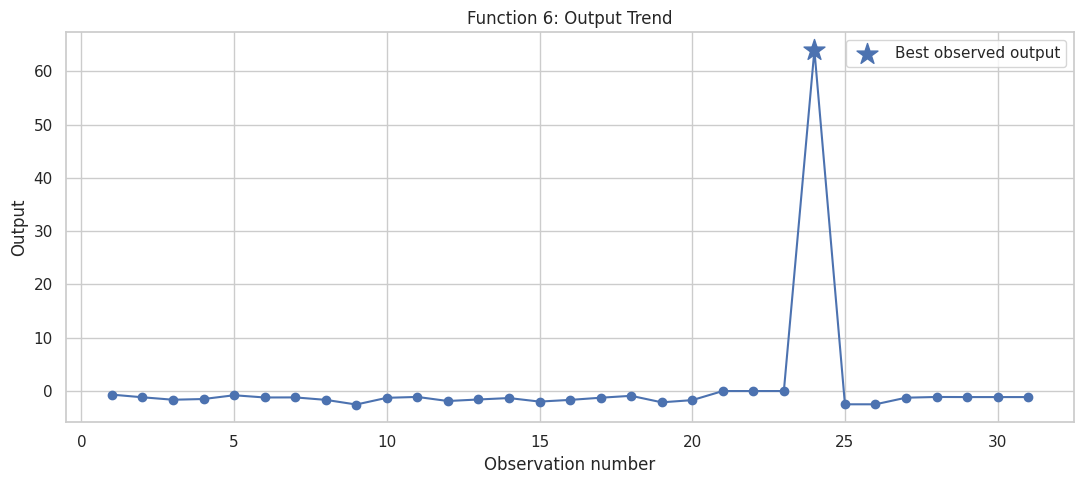

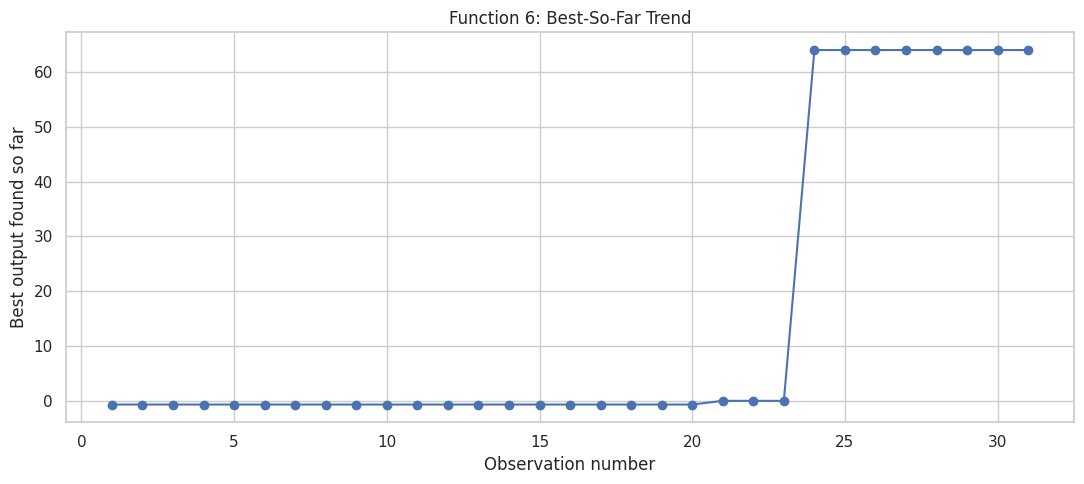

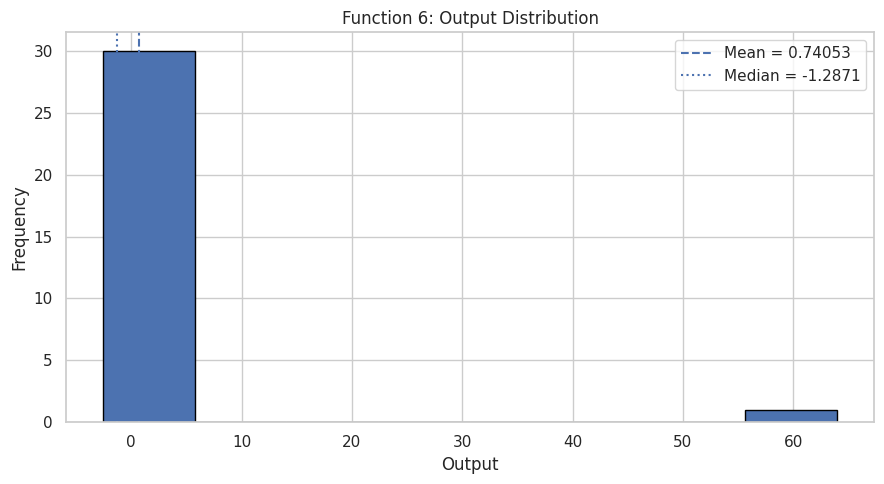

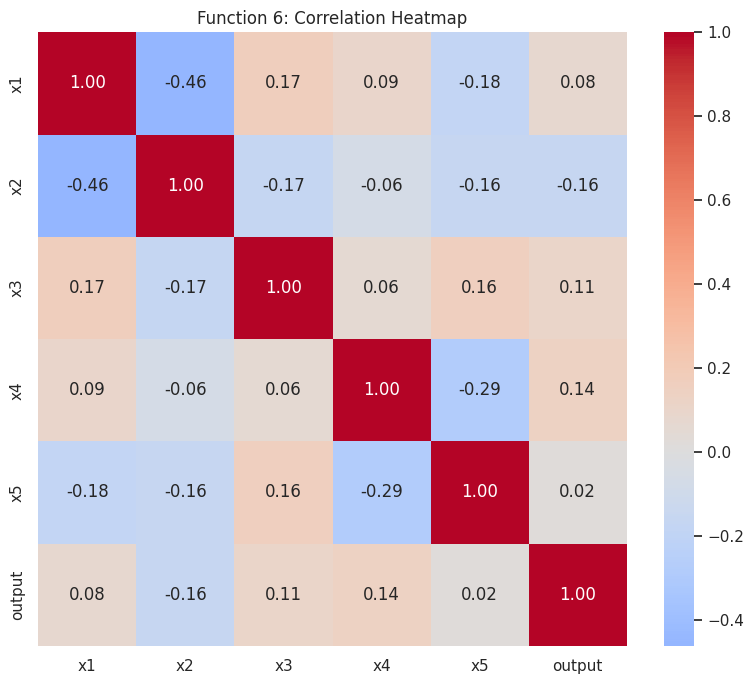

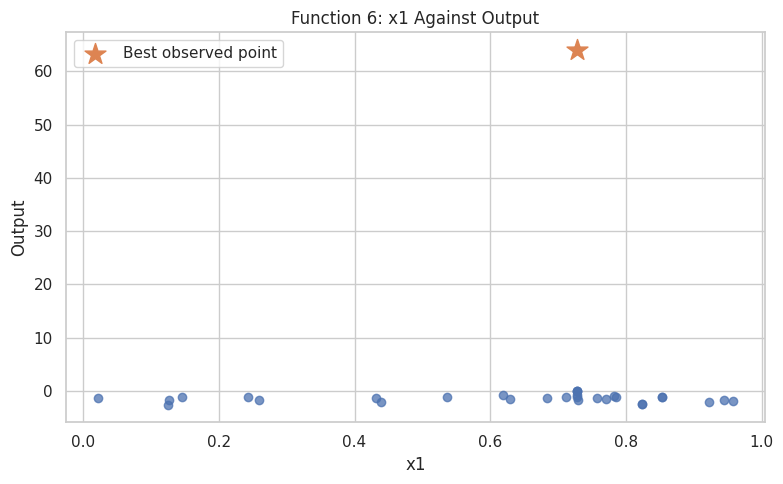

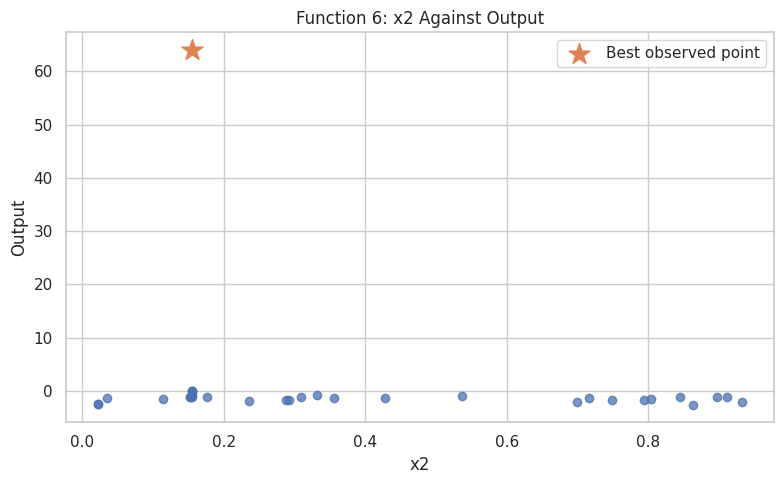

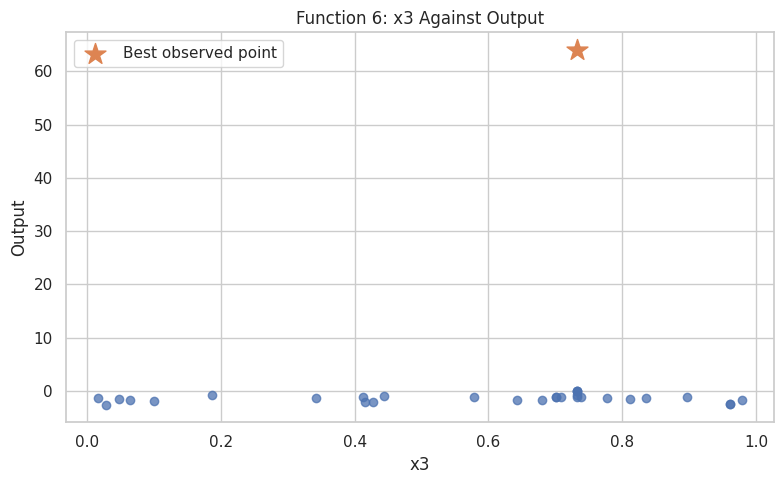

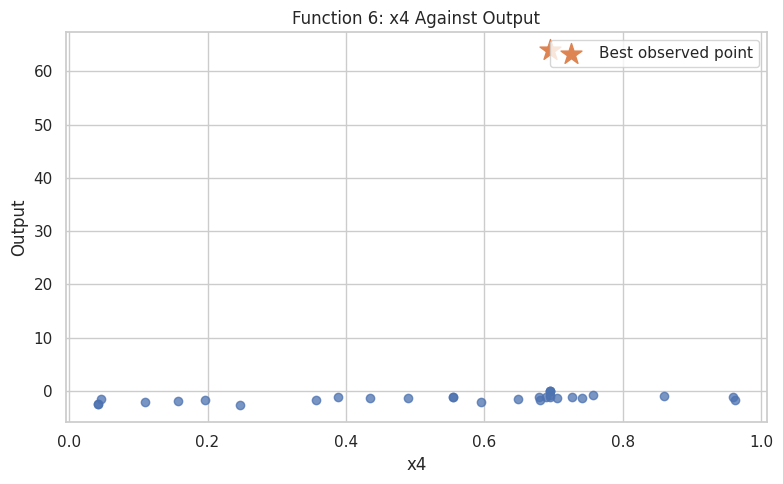

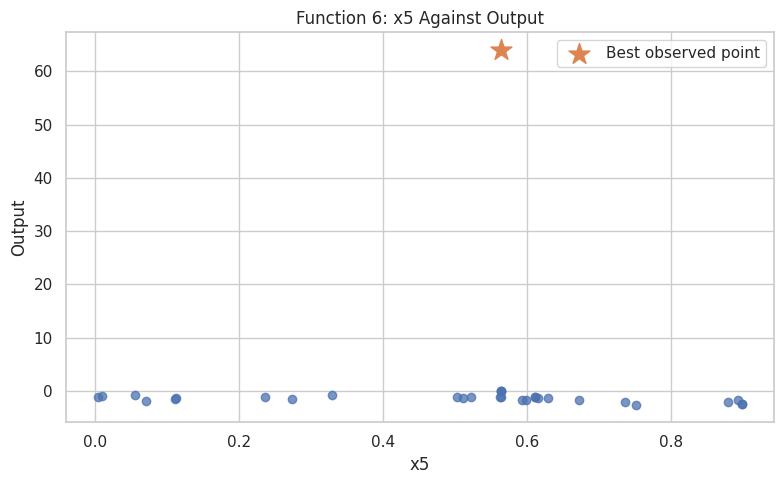


Input-output correlations
----------------------------------------
x2   -0.162652
x4    0.138517
x3    0.106068
x1    0.078399
x5    0.023811
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 31
Input dimensions   : 5
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : -2.571169632
Mean output        : 0.7405314825
Median output      : -1.287089459
Maximum output     : 64
Best observation   : 24
Best query point   : [0.728186 0.154693 0.732552 0.693997 0.564013]
Best output        : 64


In [173]:
# Conduct Function 6 EDA
eda_6 = conduct_function_eda(
    function_number=6,
    dataset_folder=week_12_folder
)



FUNCTION 7 EDA

Dataset structure
----------------------------------------
Input shape : (41, 6)
Output shape: (41,)
Observations: 41
Dimensions  : 6

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
0,0.272624,0.324495,0.897109,0.832951,0.154063,0.795864,0.604433
1,0.543003,0.924694,0.341567,0.646486,0.718440,0.343133,0.562753
2,0.090832,0.661529,0.065931,0.258577,0.963453,0.640265,0.007503
3,0.118867,0.615055,0.905816,0.855300,0.413631,0.585236,0.061424
4,0.630218,0.838097,0.680013,0.731895,0.526737,0.348429,0.273047



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
4

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,41.0,0.389838,0.328973,0.018603,0.075665,0.272624,0.722615,0.942451,0.272624,0.108224,0.351668
x2,41.0,0.455229,0.248422,0.011813,0.324122,0.520098,0.615055,0.924694,0.520098,0.061713,-0.041975
x3,41.0,0.391926,0.279782,0.003635,0.245669,0.329265,0.609084,0.924571,0.329265,0.078278,0.409655
x4,41.0,0.401312,0.324796,0.037758,0.105350,0.258577,0.731895,0.961017,0.258577,0.105492,0.600096
x5,41.0,0.455316,0.269044,0.014944,0.264514,0.434667,0.683071,0.998655,0.434667,0.072385,0.272406
x6,41.0,0.518873,0.238421,0.051100,0.359952,0.619082,0.667717,0.951014,0.619082,0.056844,-0.695404
output,41.0,6.535375,19.132483,0.002701,0.033565,0.190783,0.675142,64.000000,0.190783,366.051906,2.814782



Best observed result
----------------------------------------
Best array index       : 30
Best observation number: 31
Best query point       : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,output
33,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
31,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
32,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
30,0.045091,0.528666,0.329265,0.105350,0.434667,0.641164,64.000000
6,0.057896,0.491672,0.247422,0.218118,0.420428,0.730970,1.364968


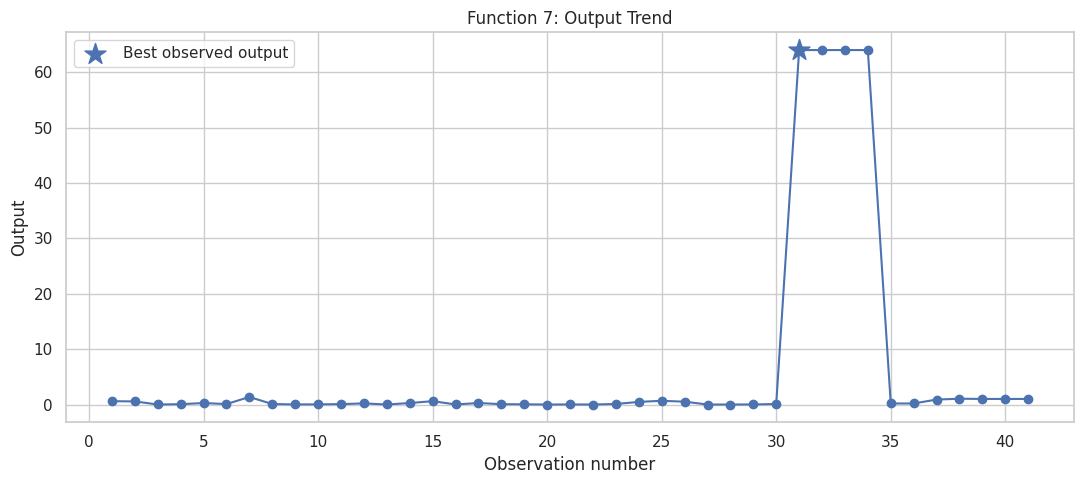

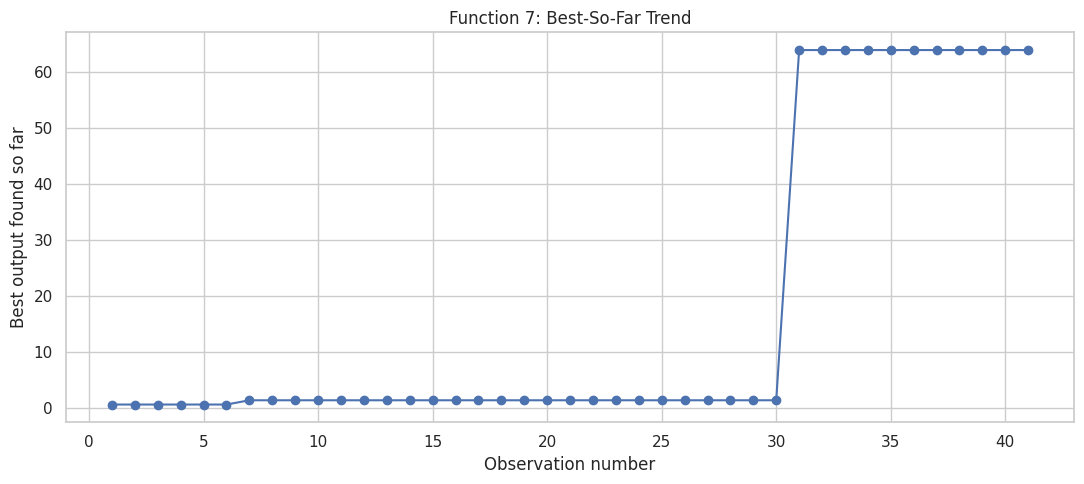

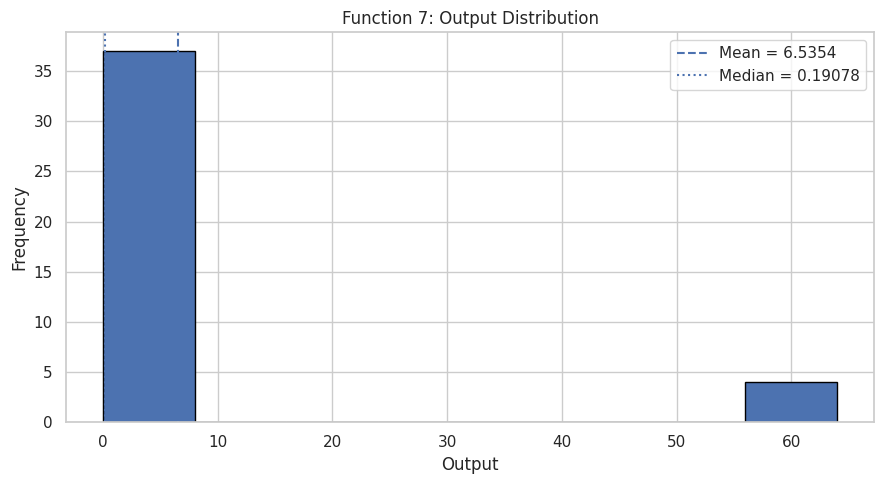

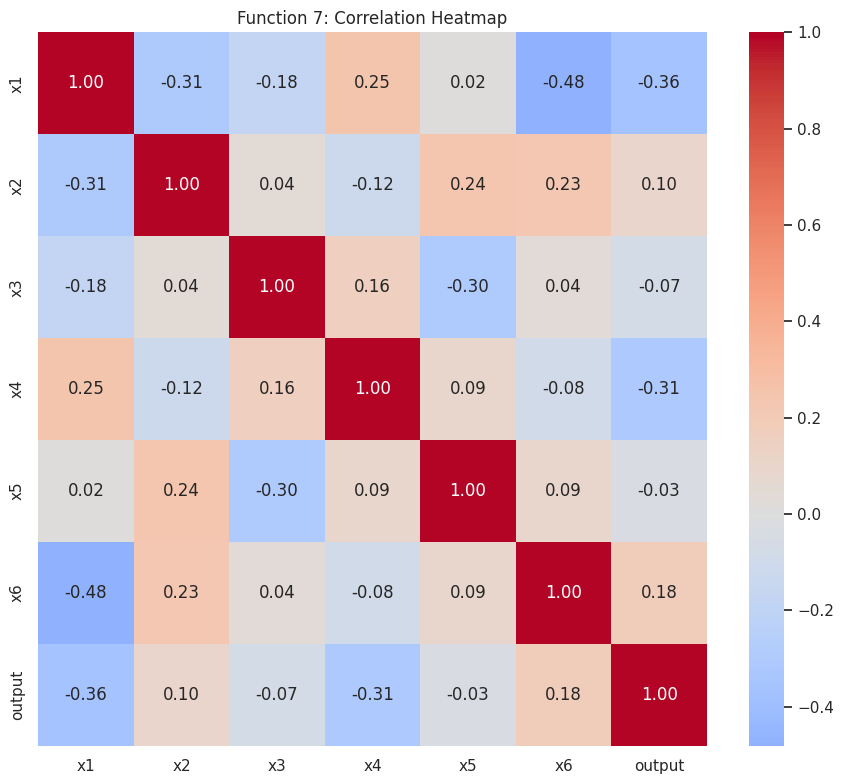

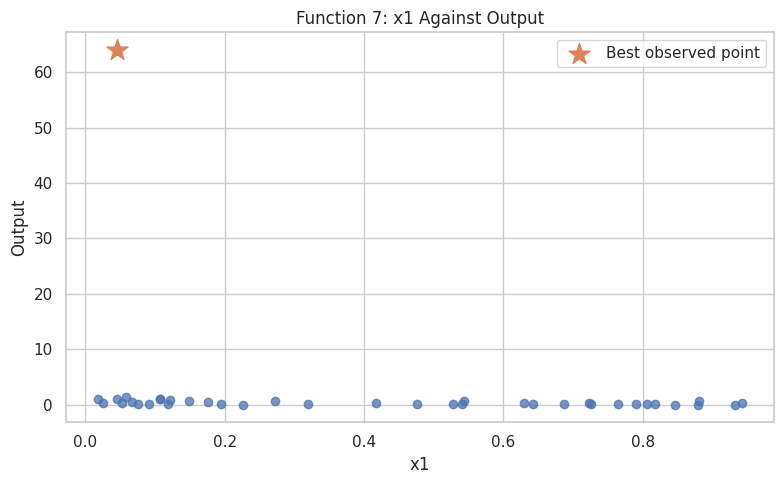

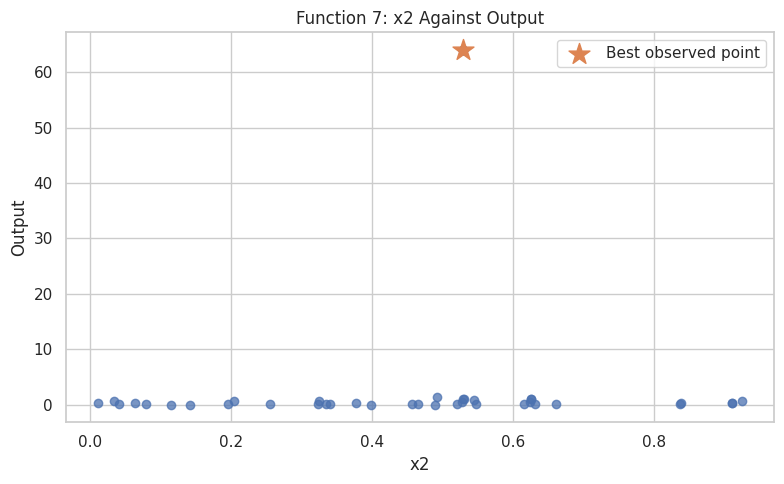

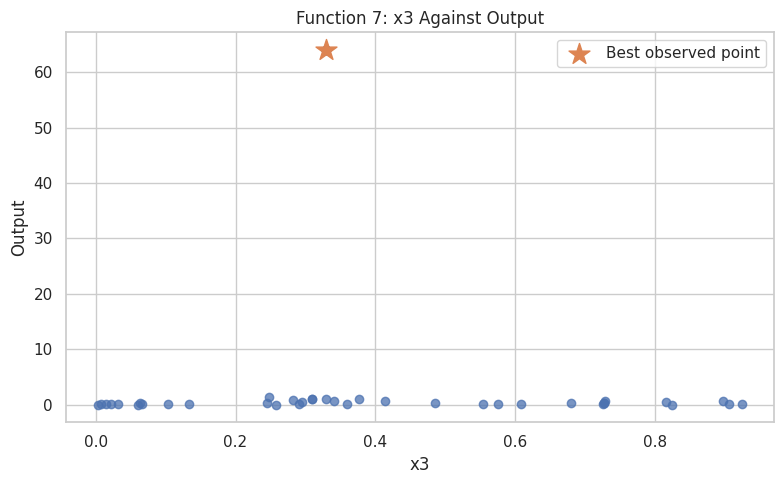

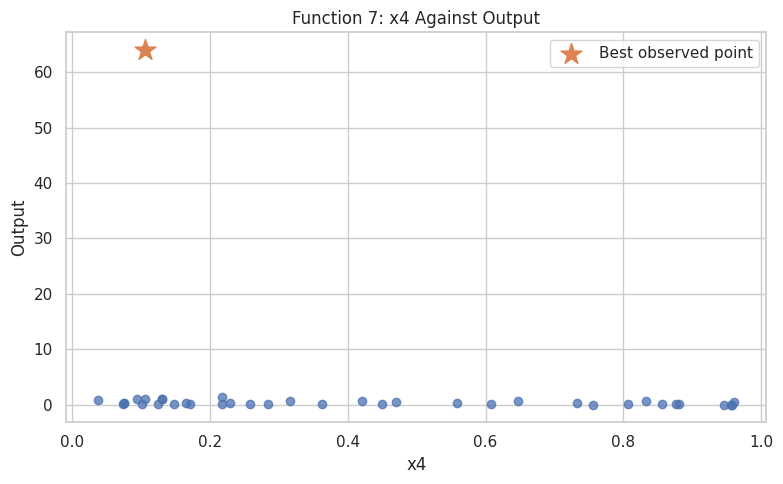

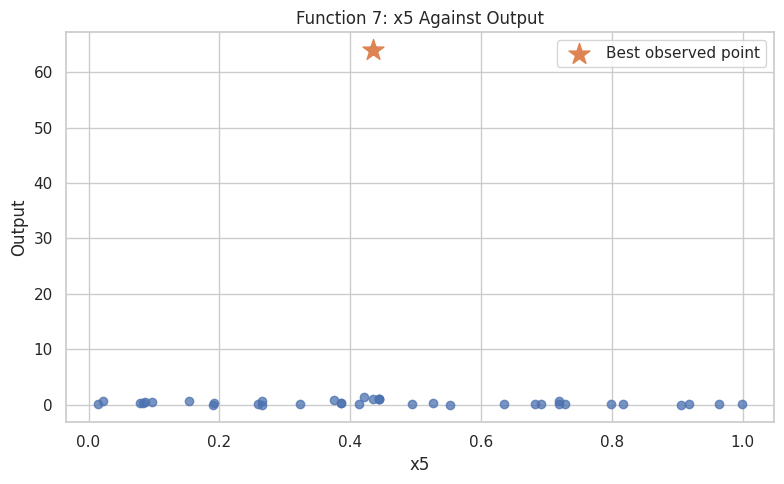

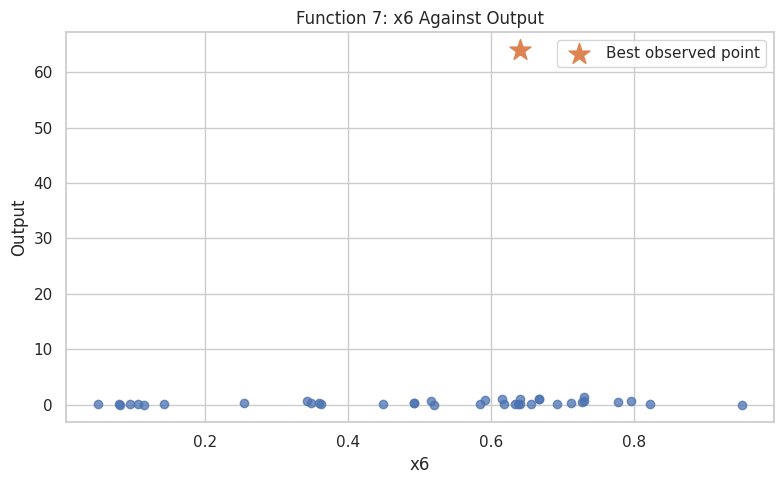


Input-output correlations
----------------------------------------
x1   -0.357760
x4   -0.309229
x6    0.177571
x2    0.101351
x3   -0.073688
x5   -0.031199
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 41
Input dimensions   : 6
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 4
Minimum output     : 0.002701465025
Mean output        : 6.535374501
Median output      : 0.1907826273
Maximum output     : 64
Best observation   : 31
Best query point   : [0.045091 0.528666 0.329265 0.10535  0.434667 0.641164]
Best output        : 64


In [174]:
# Conduct Function 7 EDA
eda_7 = conduct_function_eda(
    function_number=7,
    dataset_folder=week_12_folder
)



FUNCTION 8 EDA

Dataset structure
----------------------------------------
Input shape : (50, 8)
Output shape: (50,)
Observations: 50
Dimensions  : 8

First five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
0,0.604994,0.292215,0.908453,0.355506,0.201669,0.575338,0.310311,0.734281,7.398721
1,0.178007,0.566223,0.994862,0.210325,0.320153,0.707909,0.635384,0.107132,7.005227
2,0.009077,0.811626,0.520520,0.075687,0.265112,0.091652,0.592415,0.367320,8.459482
3,0.506028,0.653730,0.363411,0.177981,0.093728,0.197425,0.755827,0.292472,8.284008
4,0.359909,0.249076,0.495997,0.709215,0.114987,0.289207,0.557295,0.593882,8.606117



Missing values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Infinite values
----------------------------------------
x1        0
x2        0
x3        0
x4        0
x5        0
x6        0
x7        0
x8        0
output    0
dtype: int64

Duplicate rows
----------------------------------------
3

Summary statistics
----------------------------------------


,count,mean,std,min,25%,50%,75%,max,median,variance,skewness
x1,50.0,0.483951,0.305145,0.006802,0.273673,0.476658,0.776238,0.985945,0.476658,0.093113,0.065877
x2,50.0,0.436708,0.297210,0.003419,0.222209,0.384769,0.650021,0.973980,0.384769,0.088334,0.217098
x3,50.0,0.448271,0.310636,0.021301,0.165184,0.379438,0.726319,0.998885,0.379438,0.096495,0.323250
x4,50.0,0.382497,0.279247,0.000000,0.083650,0.371557,0.632657,0.902986,0.371557,0.077979,0.222252
x5,50.0,0.529789,0.290876,0.009649,0.263925,0.619797,0.771803,0.986902,0.619797,0.084609,-0.173109
x6,50.0,0.417355,0.281659,0.022113,0.230729,0.299530,0.646535,0.990244,0.299530,0.079332,0.526860
x7,50.0,0.496258,0.297007,0.035909,0.183387,0.552563,0.754113,0.992914,0.552563,0.088213,-0.082648
x8,50.0,0.450266,0.281118,0.041956,0.198253,0.378037,0.671847,0.988755,0.378037,0.079027,0.269032
output,50.0,8.127379,9.061499,-8.727516,7.173686,7.967780,8.827448,64.000000,7.967780,82.110767,4.572206



Best observed result
----------------------------------------
Best array index       : 43
Best observation number: 44
Best query point       : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output value      : 64.0

Top five observations
----------------------------------------


,x1,x2,x3,x4,x5,x6,x7,x8,output
43,0.273673,0.260400,0.073937,0.078562,0.862321,0.230729,0.108688,0.110992,64.000000
48,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.699892
49,0.546897,0.163123,0.136484,0.078398,0.771803,0.070794,0.119397,0.111488,9.699892
47,0.321258,0.232284,0.021301,0.000000,0.895967,0.249315,0.054463,0.073967,9.699892
14,0.056447,0.065956,0.022929,0.038786,0.403935,0.801055,0.488307,0.893085,9.598482


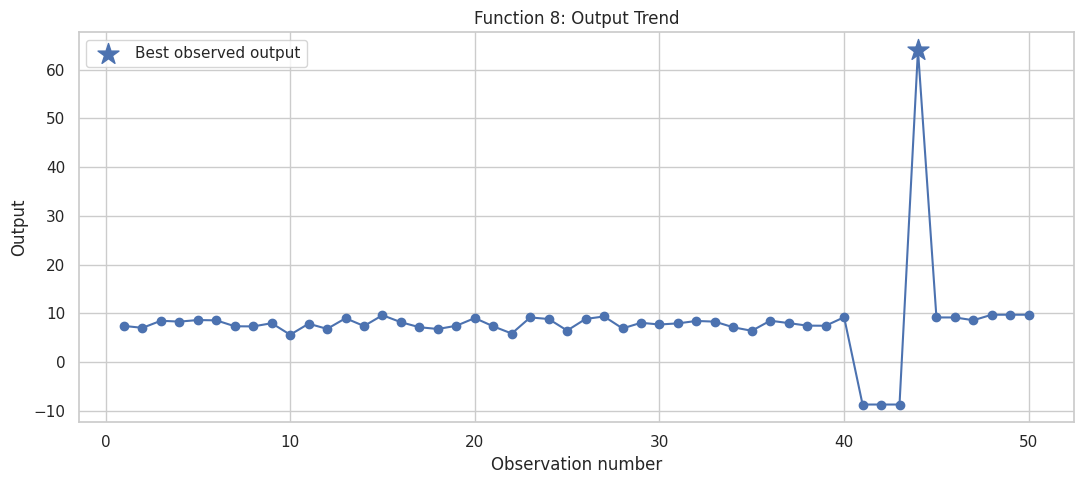

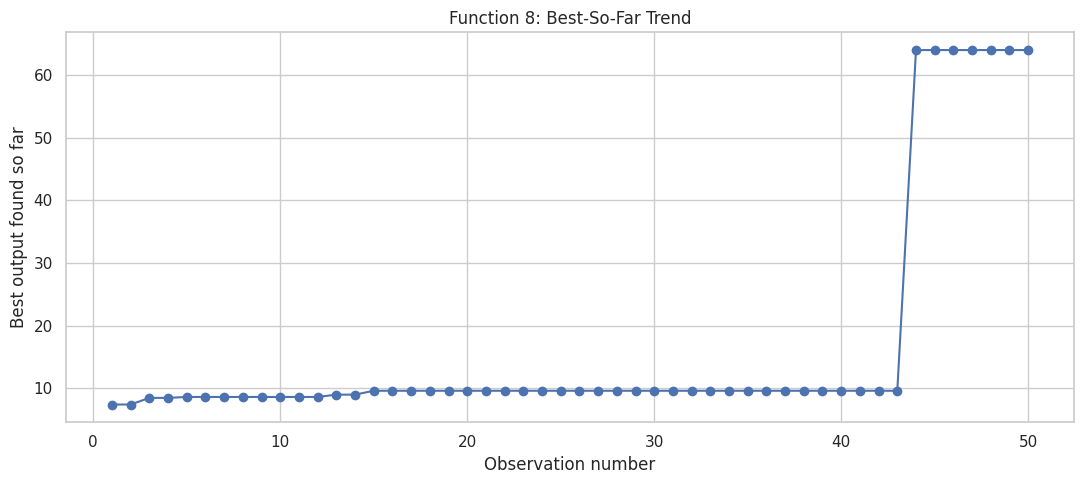

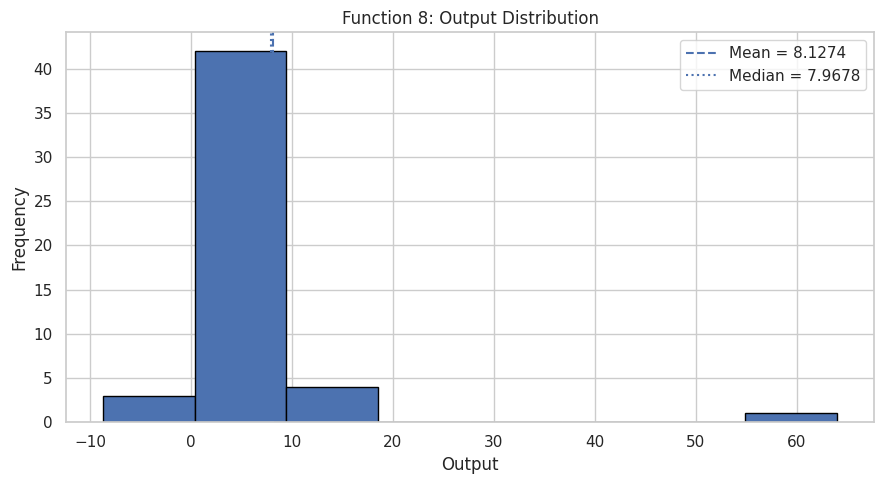

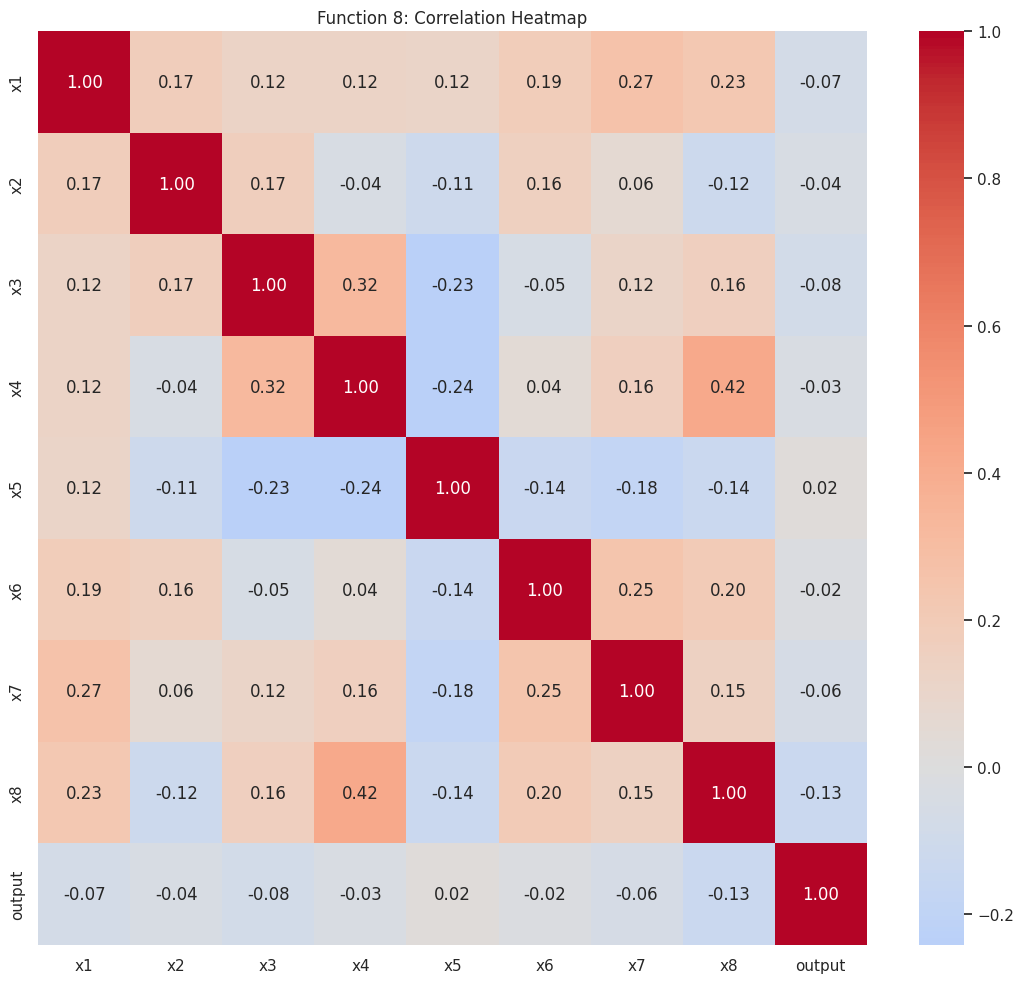

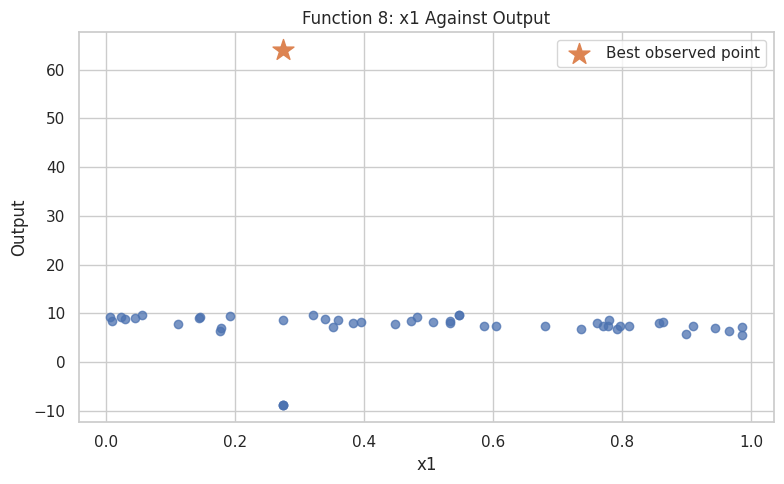

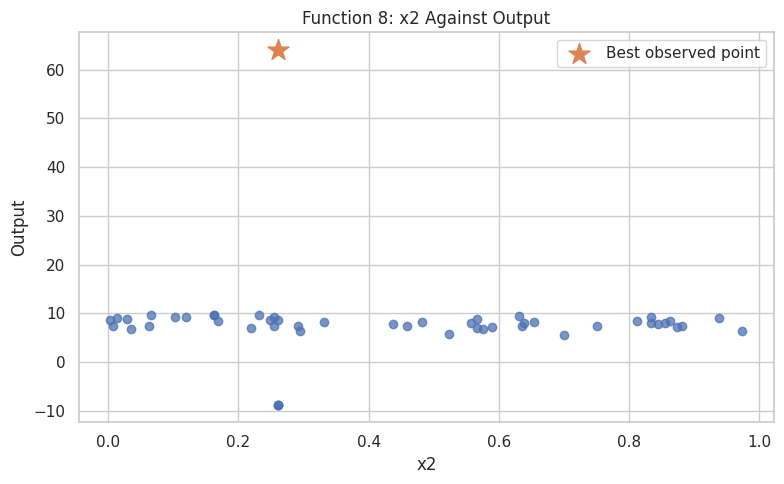

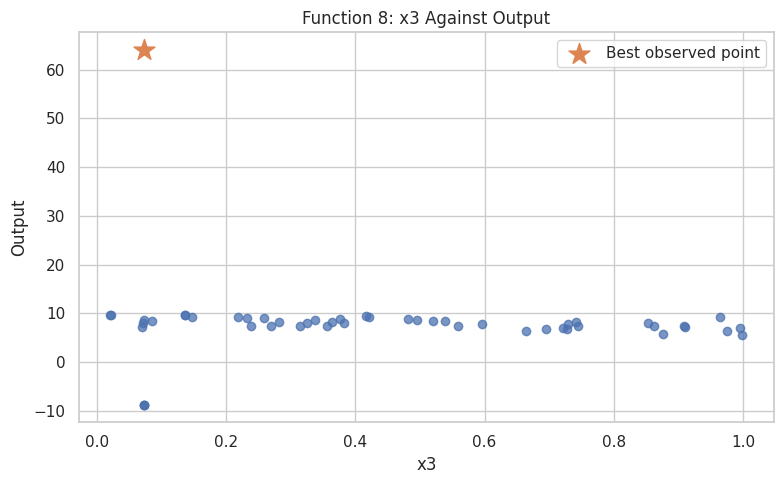

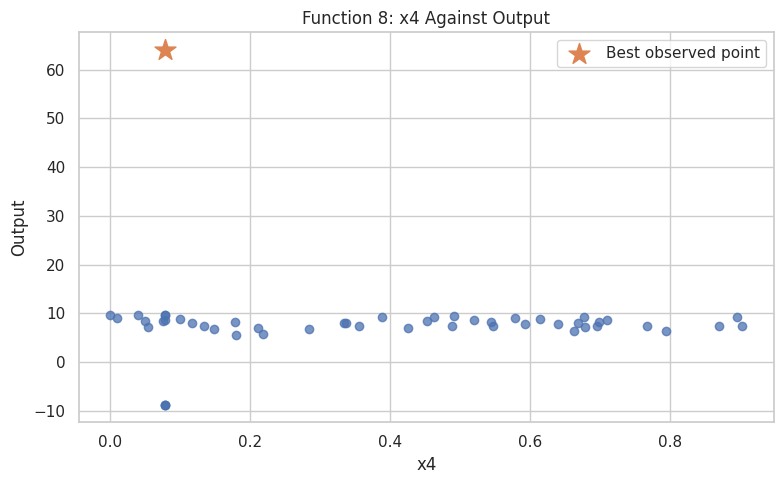

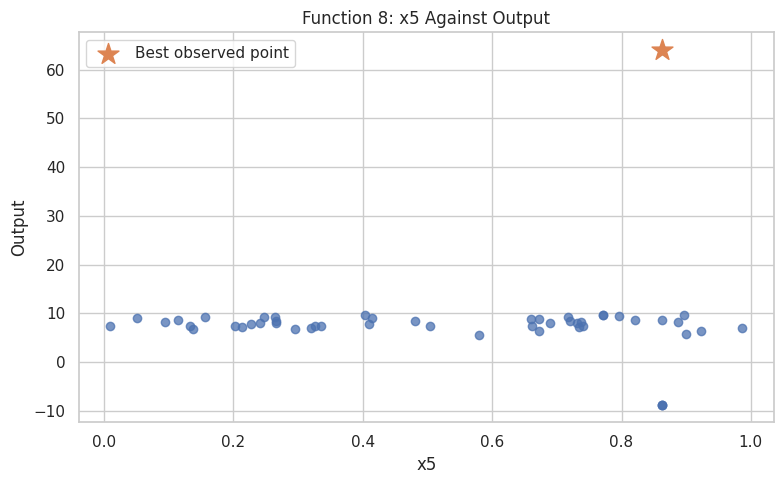

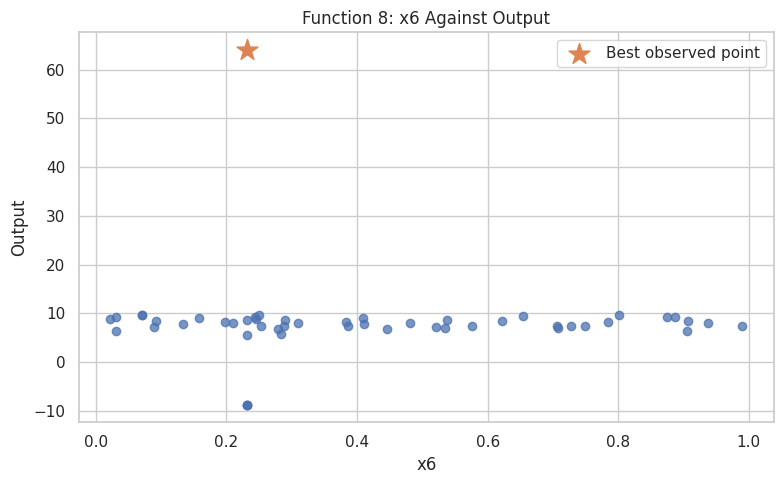

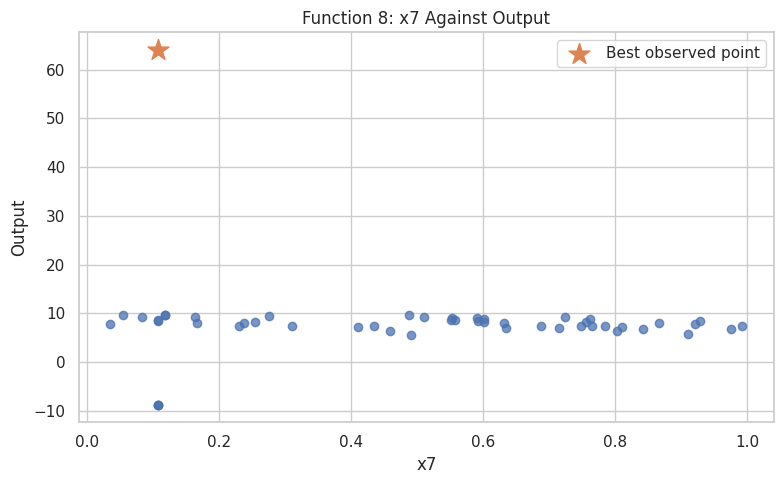

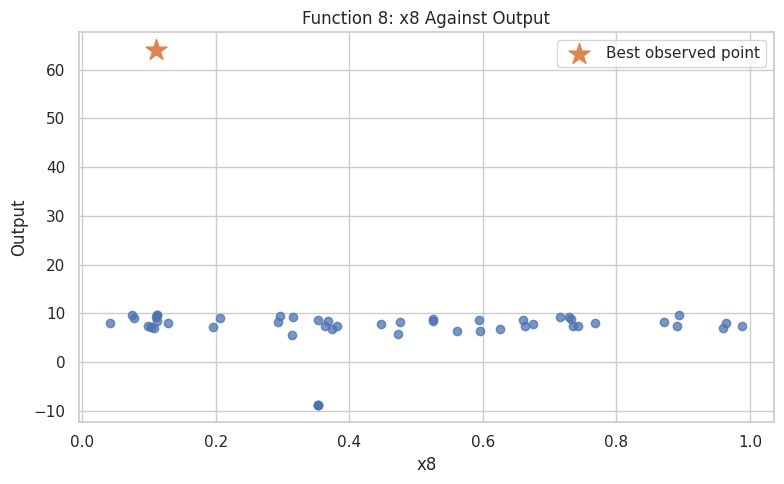


Input-output correlations
----------------------------------------
x8   -0.130897
x3   -0.079828
x1   -0.074684
x7   -0.061559
x2   -0.038989
x4   -0.032365
x6   -0.017419
x5    0.016603
Name: output, dtype: float64

Concise EDA report
----------------------------------------
Observations       : 50
Input dimensions   : 8
Missing values     : 0
Infinite values    : 0
Duplicate rows     : 3
Minimum output     : -8.727516493
Mean output        : 8.127379238
Median output      : 7.967779664
Maximum output     : 64
Best observation   : 44
Best query point   : [0.273673 0.2604   0.073937 0.078562 0.862321 0.230729 0.108688 0.110992]
Best output        : 64


In [175]:
# Conduct Function 8 EDA
eda_8 = conduct_function_eda(
    function_number=8,
    dataset_folder=week_12_folder
)

In [176]:
all_eda_results = [
    eda_1,
    eda_2,
    eda_3,
    eda_4,
    eda_5,
    eda_6,
    eda_7,
    eda_8
]

combined_summary = []

for result in all_eda_results:

    X = result["X"]
    y = result["y"]

    combined_summary.append({
        "Function": result["function"],
        "Observations": X.shape[0],
        "Dimensions": X.shape[1],
        "Minimum_Output": np.min(y),
        "Mean_Output": np.mean(y),
        "Median_Output": np.median(y),
        "Maximum_Output": np.max(y),
        "Best_Observation": result["best_index"] + 1,
        "Best_Query_Point": result["best_input"],
        "Best_Output": result["best_output"]
    })

combined_summary_df = pd.DataFrame(combined_summary)

display(combined_summary_df)

,Function,Observations,Dimensions,Minimum_Output,Mean_Output,Median_Output,Maximum_Output,Best_Observation,Best_Query_Point,Best_Output
0,1,21,2,-0.003606,12.190304,3.341771e-124,64.000000,11,"[0.37454, 0.950714]",64.000000
1,2,21,2,-0.065624,3.186353,4.940641e-02,64.000000,14,"[0.37454, 0.950714]",64.000000
2,3,26,3,-0.398926,9.767074,-6.964528e-02,64.000000,16,"[0.444444, 0.666666, 0.333333]",64.000000
3,4,41,4,-32.625660,-14.348720,-1.605377e+01,64.000000,34,"[0.555555, 0.444444, 0.222222, 0.111111]",64.000000
4,5,31,4,0.112940,187.990424,6.400000e+01,1088.859618,16,"[0.22418902330288348, 0.8464804904862864, 0.87...",1088.859618
5,6,31,5,-2.571170,0.740531,-1.287089e+00,64.000000,24,"[0.728186, 0.154693, 0.732552, 0.693997, 0.564...",64.000000
6,7,41,6,0.002701,6.535375,1.907826e-01,64.000000,31,"[0.045091, 0.528666, 0.329265, 0.10535, 0.4346...",64.000000
7,8,50,8,-8.727516,8.127379,7.967780e+00,64.000000,44,"[0.273673, 0.2604, 0.073937, 0.078562, 0.86232...",64.000000


In [177]:
# Import the required Gaussian Process classes.
from sklearn.gaussian_process import GaussianProcessRegressor
from sklearn.gaussian_process.kernels import (
    ConstantKernel,
    Matern,
    WhiteKernel,
)


Define the UCB acquisition function

For maximisation, UCB is:

 UCB(x)=mu(x)+ kappasigma(x)

where:

* mu(x) is the GP-predicted mean;
* sigma(x) is the GP uncertainty;
* κappa controls exploration;
* a larger κappa produces more exploration;
* a smaller κappa produces more exploitation.

In [178]:
def upper_confidence_bound(mean, std, kappa=2.0):
    """
    UCB acquisition function for maximisation.
    """
    return mean + (kappa * std)

In [179]:
def generate_bo_query(
    function_number,
    dataset_folder,
    kappa=0.1,
    number_of_candidates=100000,
    random_state=42,
):
    """Fit a GP and select a new, rounded query with UCB."""
    if function_number not in EXPECTED_DIMENSIONS:
        raise ValueError("function_number must be between 1 and 8.")
    if kappa < 0:
        raise ValueError("kappa must be non-negative.")
    if number_of_candidates < 1:
        raise ValueError("number_of_candidates must be positive.")

    input_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_inputs.npy",
    )
    output_path = os.path.join(
        dataset_folder,
        f"function_{function_number}_outputs.npy",
    )

    X = np.asarray(np.load(input_path), dtype=float)
    y = np.asarray(np.load(output_path), dtype=float).reshape(-1)
    expected_dimension = EXPECTED_DIMENSIONS[function_number]

    if X.ndim == 1:
        if X.size % expected_dimension:
            raise ValueError(
                f"Function {function_number}: cannot reshape {X.size} input "
                f"values to dimension {expected_dimension}."
            )
        X = X.reshape(-1, expected_dimension)

    if X.ndim != 2 or X.shape[1] != expected_dimension:
        raise ValueError(
            f"Function {function_number}: expected input shape "
            f"(n, {expected_dimension}), got {X.shape}."
        )

    if X.shape[0] != y.shape[0]:
        raise ValueError(
            f"Function {function_number}: {X.shape[0]} input rows but "
            f"{y.shape[0]} outputs."
        )

    if not np.isfinite(X).all() or not np.isfinite(y).all():
        raise ValueError(
            f"Function {function_number} contains non-finite values."
        )

    if np.any((X < 0.0) | (X > 1.0)):
        raise ValueError(
            f"Function {function_number}: inputs must lie in [0, 1]."
        )

    y_mean = np.mean(y)
    y_std = np.std(y)
    y_scaled = y - y_mean if np.isclose(y_std, 0.0) else (y - y_mean) / y_std

    dimensions = X.shape[1]
    kernel = (
        ConstantKernel(
            constant_value=1.0,
            constant_value_bounds=(1e-3, 1e3),
        )
        * Matern(
            length_scale=np.full(dimensions, 0.2),
            length_scale_bounds=(0.01, 2.0),
            nu=2.5,
        )
        + WhiteKernel(
            noise_level=1e-6,
            noise_level_bounds=(1e-10, 1e-2),
        )
    )

    gp = GaussianProcessRegressor(
        kernel=kernel,
        normalize_y=False,
        n_restarts_optimizer=10,
        random_state=random_state,
    )
    gp.fit(X, y_scaled)

    rng = np.random.default_rng(random_state + function_number)
    candidates = rng.uniform(
        low=0.0,
        high=1.0,
        size=(number_of_candidates, dimensions),
    )

    # Exclude points that duplicate an observation after submission rounding.
    observed_points = {tuple(row) for row in np.round(X, 6)}
    rounded_candidates = np.round(candidates, 6)
    is_new = np.array(
        [tuple(row) not in observed_points for row in rounded_candidates],
        dtype=bool,
    )
    candidates = candidates[is_new]
    rounded_candidates = rounded_candidates[is_new]

    if not len(candidates):
        raise RuntimeError("No unevaluated candidate points were generated.")

    predicted_mean, predicted_std = gp.predict(candidates, return_std=True)
    ucb = upper_confidence_bound(predicted_mean, predicted_std, kappa=kappa)

    best_candidate_index = int(np.argmax(ucb))
    next_query_rounded = rounded_candidates[best_candidate_index]
    submission_query = "-".join(
        f"{value:.6f}" for value in next_query_rounded
    )

    return {
        "function": function_number,
        "query_array": next_query_rounded,
        "submission_query": submission_query,
        "predicted_mean_scaled": predicted_mean[best_candidate_index],
        "predicted_std_scaled": predicted_std[best_candidate_index],
        "ucb_value": ucb[best_candidate_index],
        "fitted_kernel": gp.kernel_,
    }


In [180]:
# Function 1 Query
week_12_folder = "/content/drive/MyDrive/week_12_dataset"

query_1 = generate_bo_query(
    function_number=1,
    dataset_folder=week_12_folder,
    kappa=0.1,
    number_of_candidates=100000,
    random_state=42
)

print("Function 1 query:")
print(query_1["submission_query"])

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1 query:
0.379342-0.952033


In [154]:
all_queries = {}

for function_number in range(1, 9):

    result = generate_bo_query(
        function_number=function_number,
        dataset_folder=week_12_folder,
        kappa=0.1,
        number_of_candidates=100000,
        random_state=42
    )

    all_queries[function_number] = result

    print(
        f"Function {function_number}: "
        f"{result['submission_query']}"
    )

/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 1: 0.379342-0.952033


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k2__noise_level is close to the specified upper bound 0.01. Increasing the bound and calling fit again may find a better value.
  warnings.warn(


Function 2: 0.375969-0.960086


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Converg

...

Function 6: 0.678590-0.144728-0.730278-0.715653-0.604728


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified lower bound 0.01. Decreasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:442: Converge

Function 7: 0.280913-0.512275-0.321637-0.188234-0.420546-0.641027


/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 0 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 1 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: ConvergenceWarning: The optimal value found for dimension 2 of parameter k1__k2__length_scale is close to the specified upper bound 2.0. Increasing the bound and calling fit again may find a better value.
  warnings.warn(
/usr/local/lib/python3.12/dist-packages/sklearn/gaussian_process/kernels.py:452: Convergenc

Function 8: 0.336333-0.357149-0.357385-0.258648-0.435905-0.238153-0.224757-0.113002


In [181]:
# Print only the submission strings
print("WEEK 12 QUERY POINTS")
print("=" * 50)

for function_number in range(1, 9):
    print(all_queries[function_number]["submission_query"])

WEEK 12 QUERY POINTS
0.379342-0.952033
0.375969-0.960086
0.450034-0.667941-0.342989
0.514540-0.373212-0.258372-0.111039
0.055102-0.907391-0.645419-0.934811
0.678590-0.144728-0.730278-0.715653-0.604728
0.280913-0.512275-0.321637-0.188234-0.420546-0.641027
0.336333-0.357149-0.357385-0.258648-0.435905-0.238153-0.224757-0.113002


In [183]:
submission_file = os.path.join(
    week_12_folder,
    "week_12_query_points.txt",
)

with open(submission_file, "w", encoding="utf-8") as file:
    for function_number in range(1, 9):
        query_string = all_queries[function_number]["submission_query"]
        file.write(f"Function_{function_number}:{query_string}\n")

print("Saved to:")
print(submission_file)


Saved to:
/content/drive/MyDrive/week_12_dataset/week_12_query_points.txt
